In [1]:
from obspy import UTCDateTime
import obspy
from obspy.clients.fdsn import Client
import random
from obspy.clients.fdsn import RoutingClient
from obspy import Stream
from obspy.geodetics import gps2dist_azimuth
from obspy import signal
from obspy import read
import csv
import matplotlib.pyplot as plt
import folium
import numpy as np
import json
import pandas as pd
from obspy.clients.fdsn.header import FDSNNoDataException
from scipy.signal import savgol_filter
import os
import folium
import numpy as np
import branca.colormap as cm
from scipy.signal import resample
from obspy import Stream
from matplotlib.colors import LogNorm

from shapely.geometry import box, LineString
from collections import defaultdict
from tqdm import tqdm






import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection






from plotting_routines import *
from processing_routines import *
Dtmin_Noise=-25
Dtmax_Noise=-5
Dtmin_Pn=-5.
Dtmax_Pn=10.
Dtmin_Sn=-5.
Dtmax_Sn=10.

vLg_max=3.5
vLg_min=3.1
vLg=0.5*(vLg_max+vLg_min)
vPg_max=6.2
vPg_min=5.2
vPg=0.5*(vPg_max+vPg_min)
print(vPg)
#vPg=6.

tminCoda=300.
tmaxCoda=320.
import warnings
warnings.filterwarnings("ignore")

5.7


In [2]:
from obspy.taup import TauPyModel

model = TauPyModel(model='ak135') #crust at 35 (?) , but only 3s difference with 11km crust 
t_Pn=111.*1/8.  #default value

arrivals = model.get_travel_times(source_depth_in_km=0,
                                distance_in_degree=1,phase_list=["Pn"])


try:
    t_Pn=arrivals [0].time +25
    print('Pn ', t_Pn)
    print('velocity Pn ',111/(t_Pn-25))
except Exception as e:
    print('no Pn ', 1, e)

Pn  46.273001774095945
velocity Pn  5.217881386874338


In [2]:
fmin = 0.5
fmax = 1.5
frequenciesmin = [0.5,2,4,6]
frequenciesmax = [1.5,3,6,8]
event_file='/home/schreinl/Stage/Data/big_box_4.5.csv'
best_bet = ['MLS','GRA1','SSB','BFO','LOR','SENIN','HASLI','BOURR','BNALP','DAVOX','FUORN','MOA','CONA','CLUD','OBKA','MONC','CIMO','ECH']

#calculate the site terms 
dict_test = create_coda_amplitude_dict(event_file='/home/schreinl/Stage/Data/big_box_4.5.csv', codawindow="cutoff", factor=1.1, fmin=fmin, fmax=fmax, data_dir='Data1',envelope_name='new')
ref_value_test = reference_stations_median(best_bet,event_file, fmin, fmax, envelope_name='new')
sites_effect_dict_test = site_effect_dict(event_file, fmin,fmax,best_bet,envelope_name='new')

site_effects = site_effect_overall(fmin,fmax,best_bet,frequenciesmin=frequenciesmin, frequenciesmax=frequenciesmax,method='multiple',map_plot=False,envelope_name='new')
filtered_site_effects = {}
for freq_band, stations in site_effects.items():
    filtered_site_effects[freq_band] = {
        station: data for station, data in stations.items() if data.get("num_points_after", 0) >= 5
    }

all_site_terms = {}
for freq_band, stations in site_effects.items():
    all_site_terms[freq_band] = {
        station: data for station, data in stations.items() if data.get("num_points_after", 0) >= 0
    }

carte = map_site_effect(fmin, fmax, filtered_site_effects, method='multiple')
#carte.save(f"site_effect_{(fmin+fmax)/2}_Hz_map.html")
carte

done reading in


## Start tomography with Seislib

First the input data has to be brought into the correct shape. 

We can write the path specific inverse of the attenuation Q as $$  \alpha_{k,l} = - \frac{V}{\pi f R_{k,l}} ln \Bigl ( \frac{A_{k,l}}{S_k P_l} R_{k,l}^{5/6} \Bigr )$$, which is the same as the formulation of Q:



$$ Q_{k,l} = \frac{-\pi r f }{V} \left( ln(\frac{A_{k,l}}{G(r)}) - ln(P_l(f)) - ln(S_k(f))\right) ^{-1}. $$

Calculating now all path specific Q values, we can quickly find the correct shape of data input for the inversion.
Now we have to put our input data into the right shape. Seislib demands a matrix of shape (n,5), n being the amount of path specific measurements, while the columns are lat1, lon1, lat2, lon2 and velocity. As mentioned above,




Processing complete.
209 events in total
20 events dropped due to insufficient std on Q0
7 events dropped due to insufficient data points
Processed 182 events with Q0 and Sk values.
-------------------------------------
GRID PARAMETERS
Lonmin - Lonmax : -2.827 - 20.173
Latmin - Latmax : 40.078 - 52.078
Number of cells : 276
Grid cells of 1.000° : 276
-------------------------------------
DATA PARAMETERS
Lonmin - Lonmax data : -2.827 - 19.948
Latmin - Latmax data : 40.078 - 51.966
Number of measurements : 51338
Source : Unknown
-------------------------------------

40.0783 51.9663 -2.8274 19.9477
*** GRID UPDATED ***
-------------------------------------
GRID PARAMETERS
Lonmin - Lonmax : -2.827 - 20.173
Latmin - Latmax : 40.078 - 52.078
Number of cells : 276
Grid cells of 1.000° : 276
-------------------------------------
*** GRID UPDATED ***
-------------------------------------
GRID PARAMETERS
Lonmin - Lonmax : -2.827 - 20.173
Latmin - Latmax : 40.078 - 52.078
Number of cells : 245
G

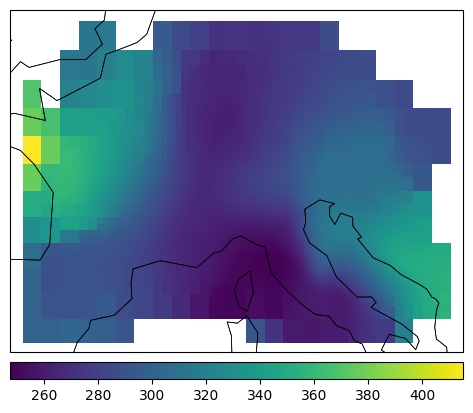

In [15]:
# finding all path specific Q values:
from seislib.tomography import SeismicTomography
from scipy.stats import zscore
fmin = 0.5
fmax = 1.5
Qkl = Lg_Q_kl(fmin, fmax,special_site_terms=filtered_site_effects)
matrix = []

for event_id, event_data in Qkl.items():
    event_coords = event_data['coordinates'] 
    stations = event_data['stations']  

    for station, station_data in stations.items():
        station_coords = station_data.get('coordinates', {})
        qkl_value = station_data.get('Qkl', None)

        if event_coords and station_coords and qkl_value is not None:
            row = [
                event_coords.get('latitude'),  
                event_coords.get('longitude'),  
                station_coords.get('latitude'),  
                station_coords.get('longitude'), 
                qkl_value  
            ]
            matrix.append(row)


matrix = np.array(matrix)#[:5000, :]

#matrix[:, -1] = np.clip(matrix[:, -1], 180, 450)


#z_scores = zscore(matrix[:, -1])
#z_threshold = 1
#matrix = matrix[np.abs(z_scores) <= z_threshold]


matrix = matrix[(matrix[:, -1] > 150) & (matrix[:, -1] <= 800)]
matrix = matrix[~np.isinf(matrix).any(axis=1)]
matrix = matrix[~np.isnan(matrix).any(axis=1)]








#do the tomography with Seislib


#tomo = SeismicTomography(cell_size=1, regular_grid=False, verbose=True)
tomo = SeismicTomography(cell_size=1, 
                         regular_grid=True, 
                        latmin=40.078,
                             latmax=51.966,
                             lonmin=-2.827 ,
                             lonmax=19.948,
                         verbose=True)

tomo.add_data(data=matrix)
print(tomo.latmin_data,tomo.latmax_data,tomo.lonmin_data,tomo.lonmax_data)

tomo.grid.set_boundaries(latmin=tomo.latmin_data,
                             latmax=tomo.latmax_data,
                             lonmin=tomo.lonmin_data,
                             lonmax=tomo.lonmax_data)


tomo.compile_coefficients(keep_empty_cells=False)

tomo.refine_parameterization(hitcounts=150,keep_empty_cells=True)    
tomo.refine_parameterization(hitcounts=150,keep_empty_cells=True)    
tomo.refine_parameterization(hitcounts=150,keep_empty_cells=True)    

slowness = 1 / matrix[:, -1]


Q = 1/tomo.solve(rdamp=0.05, ndamp=0.002)
print(tomo.refvel)
print(max(Q))
print(min(Q))
print(np.mean(Q))
print(np.std(Q))
tomo.plot_map(tomo.grid.mesh, Q)

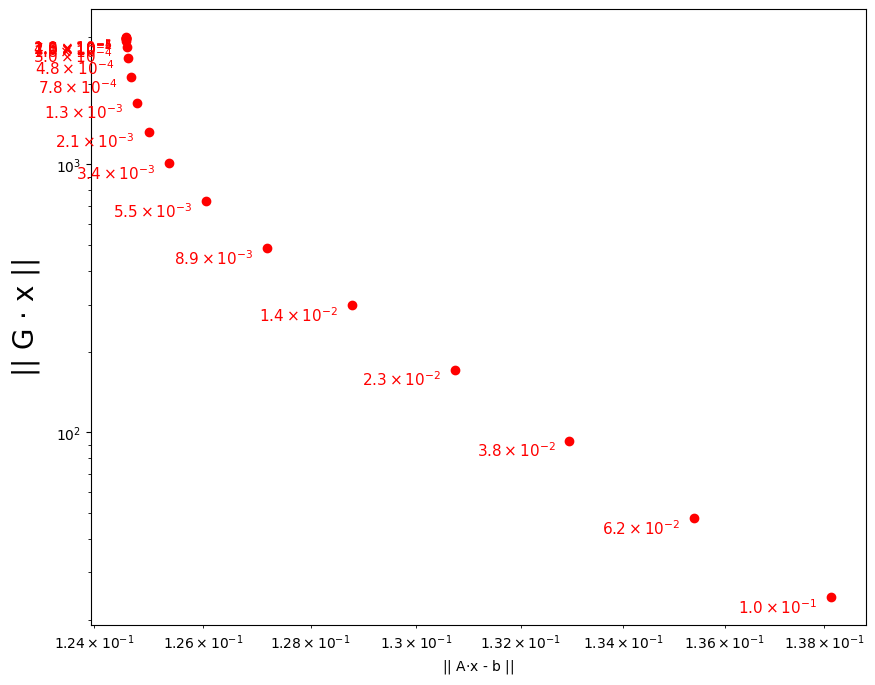

In [9]:
l = tomo.lcurve()

In [ ]:
def tomo_Q(fmin,fmax):
    '''
    Function to do all the processing, as well as plotting of Lg Q

    Input:
        - fmin: float, minimum frequency
        - fmax: float, maximum frequency


    '''

    

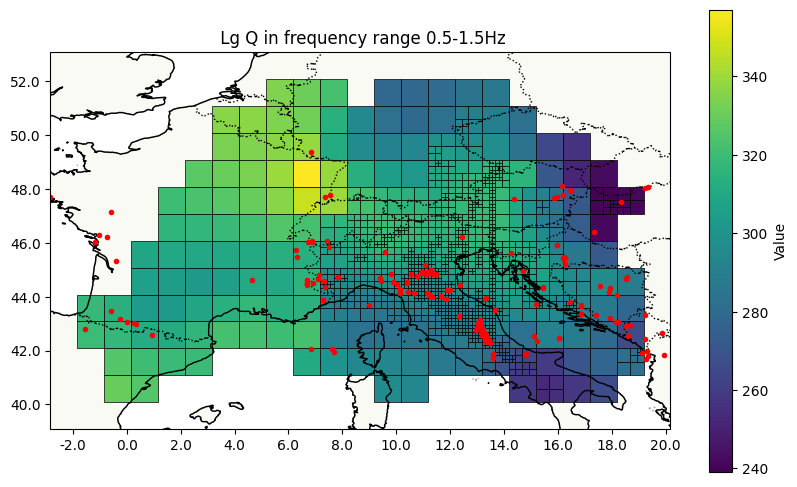

In [6]:
def plot_seislib_grid(meshndarray, c,Qkl=Qkl):
    fig = plt.figure(figsize=(10, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())

    min_lon = np.min(np.minimum(meshndarray[:, 2], meshndarray[:, 3]))
    max_lon = np.max(np.maximum(meshndarray[:, 2], meshndarray[:, 3]))
    min_lat = np.min(np.minimum(meshndarray[:, 0], meshndarray[:, 1]))
    max_lat = np.max(np.maximum(meshndarray[:, 0], meshndarray[:, 1]))

    padding = 1.0
    ax.set_extent([min_lon - padding, max_lon + padding, 
                   min_lat - padding, max_lat + padding], crs=ccrs.PlateCarree())

    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.LAND, edgecolor='black', alpha=0.3)

    patches = []
    colors = []

    for i in range(meshndarray.shape[0]):
        lat1, lat2, lon1, lon2 = meshndarray[i]
        lon = min(lon1, lon2)
        lat = min(lat1, lat2)
        width = abs(lon2 - lon1)
        height = abs(lat2 - lat1)
        rect = Rectangle((lon, lat), width, height)
        patches.append(rect)
        colors.append(c[i])

    p = PatchCollection(patches, cmap='viridis', edgecolor='k', linewidth=0.5)
    p.set_array(np.array(colors))
    ax.add_collection(p)

    from matplotlib.ticker import FuncFormatter

    def fixed_formatter(x, pos):
        return f"{x:.0f}" 

    cb = plt.colorbar(p, ax=ax, orientation='vertical', label='Value')
    cb.ax.yaxis.set_major_formatter(FuncFormatter(fixed_formatter))    

    ax.set_xticks(np.arange(np.floor(min_lon), np.ceil(max_lon) + 1, 2))
    ax.set_yticks(np.arange(np.floor(min_lat), np.ceil(max_lat) + 1, 2))
    ax.set_xticklabels(np.arange(np.floor(min_lon), np.ceil(max_lon) + 1, 2))
    ax.set_yticklabels(np.arange(np.floor(min_lat), np.ceil(max_lat) + 1, 2))
    for event_data in Qkl.values():
        event_coords = event_data["coordinates"]

        valid_station_found = False
        for station_code, station_info in event_data.get("stations", {}).items():
            if station_info.get("Qkl") is not None:
                valid_station_found = True
                break 

        if valid_station_found: 
            ax.plot(event_coords["longitude"], event_coords["latitude"],
                    'ro', markersize=3, transform=ccrs.PlateCarree(), label="Event")
    ax.set_title(f" Lg Q in frequency range {fmin}-{fmax}Hz")
    plt.show()


plot_seislib_grid(tomo.grid.mesh, Q)

Damping value: 0.0001


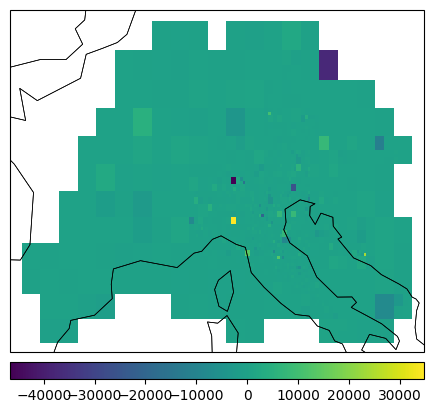

Damping value: 0.0002754228703338166


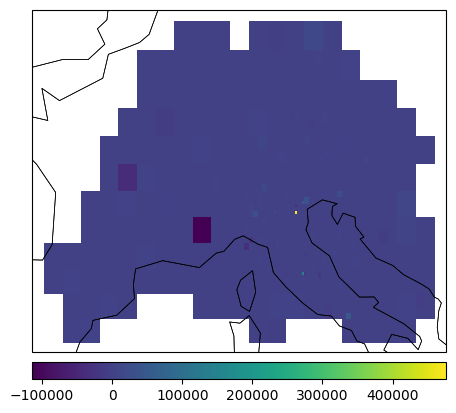

Damping value: 0.0007585775750291835


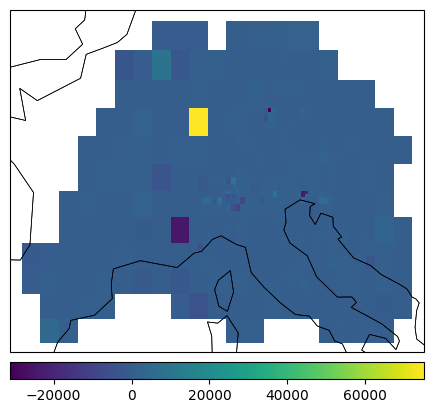

Damping value: 0.0020892961308540407


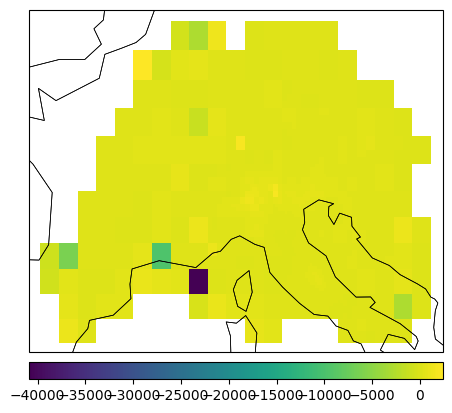

Damping value: 0.005754399373371567


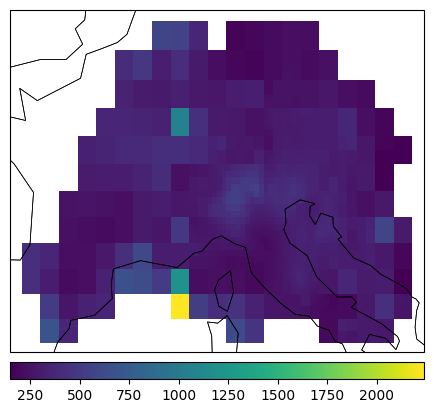

Damping value: 0.01584893192461114


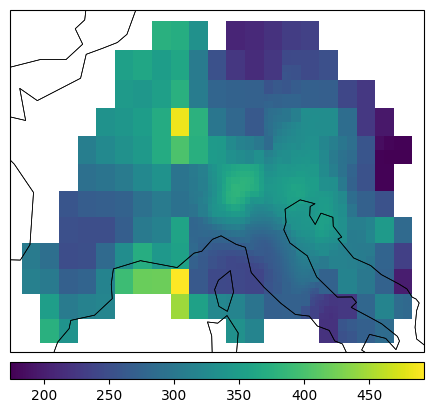

Damping value: 0.04365158322401661


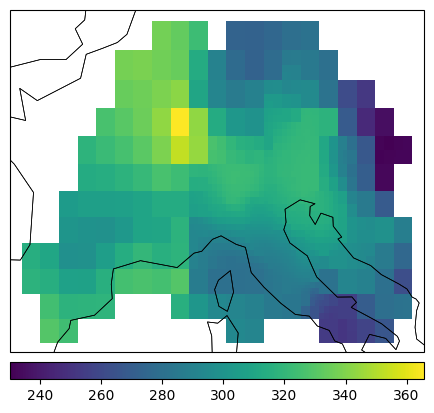

Damping value: 0.12022644346174131


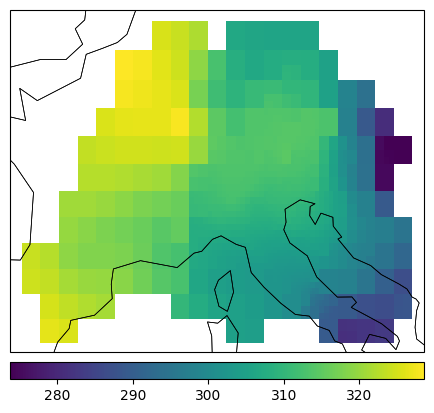

Damping value: 0.3311311214825911


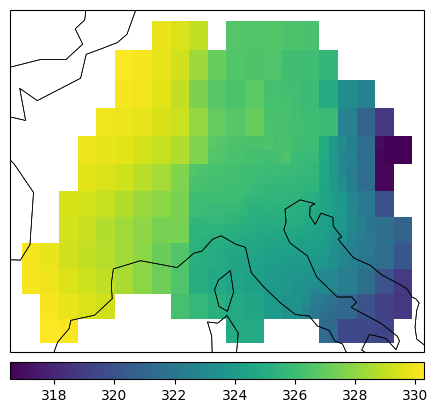

Damping value: 0.9120108393559097


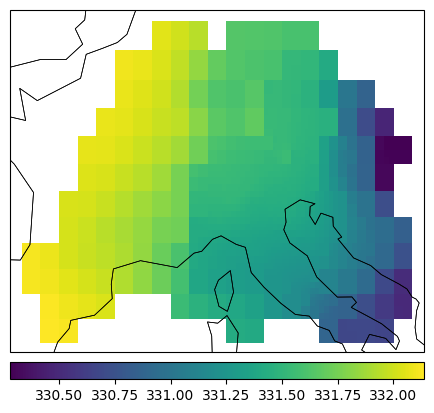

Damping value: 2.5118864315095824


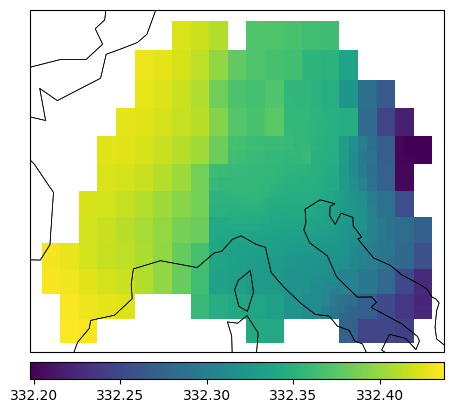

Damping value: 6.918309709189363


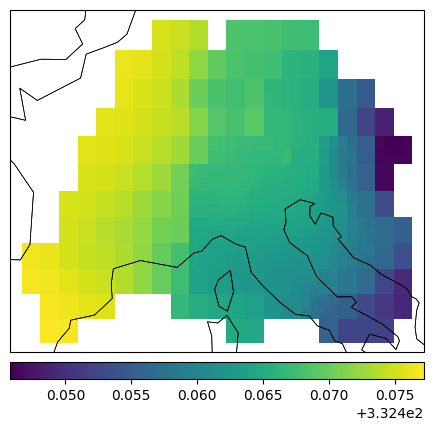

Damping value: 19.054607179632484


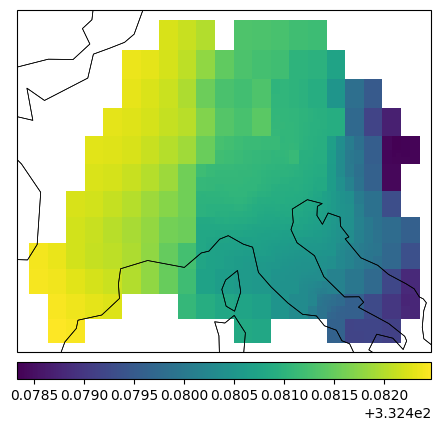

Damping value: 52.48074602497723


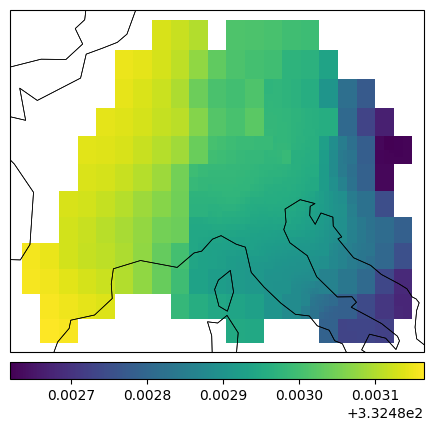

Damping value: 144.5439770745928


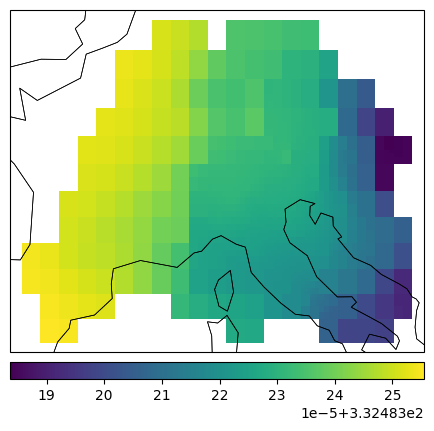

Damping value: 398.1071705534969


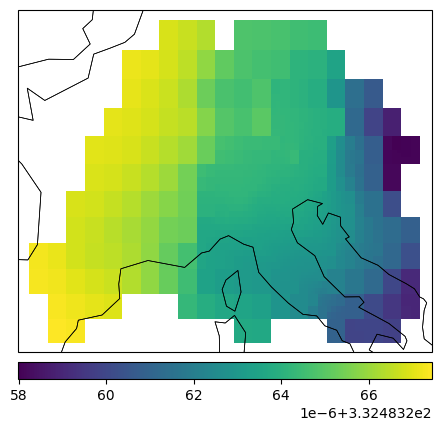

Damping value: 1096.4781961431852


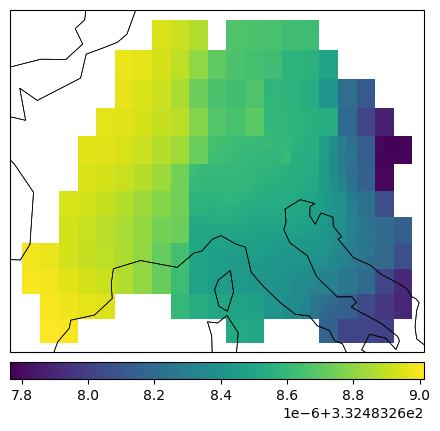

Damping value: 3019.951720402019


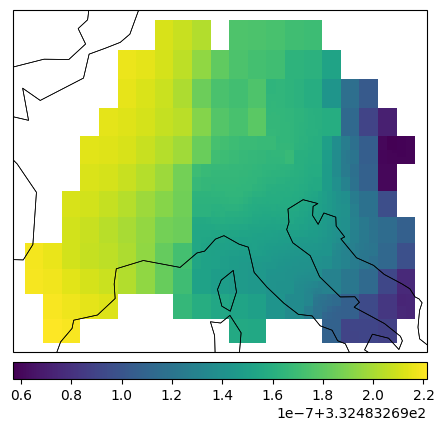

Damping value: 8317.63771102671


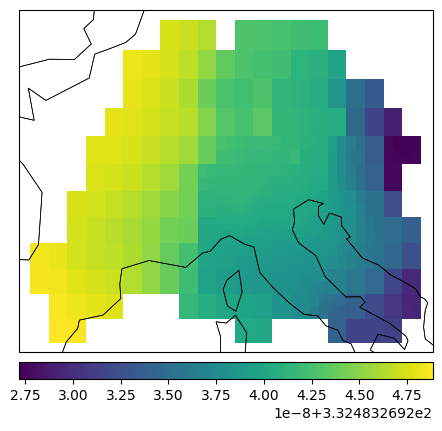

Damping value: 22908.6765276777


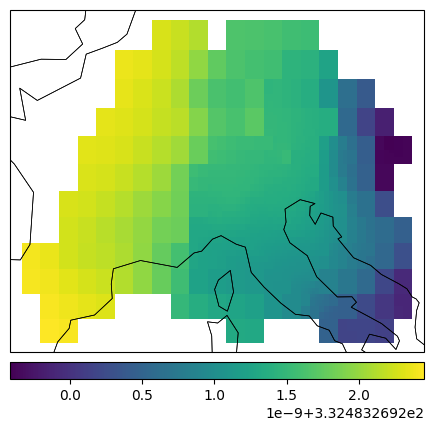

Damping value: 63095.73444801943


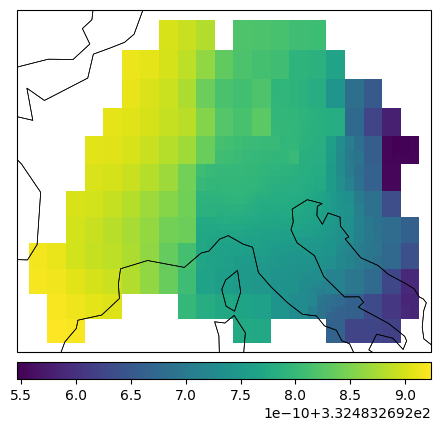

Damping value: 173780.08287493762


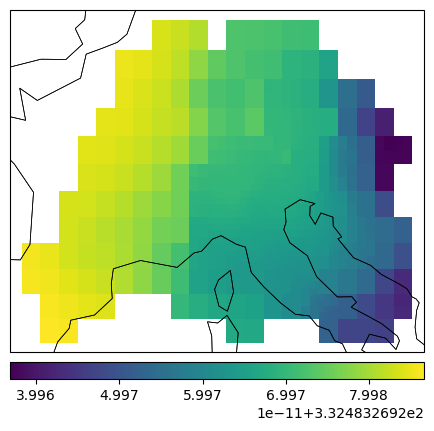

Damping value: 478630.092322638


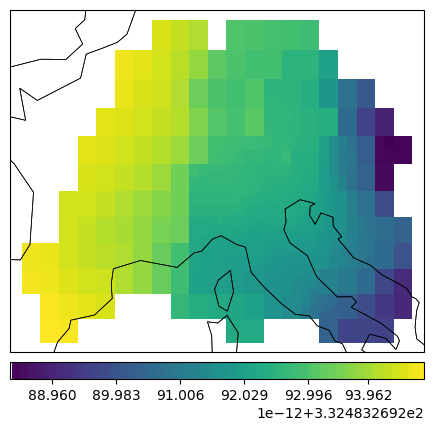

Damping value: 1318256.7385564048


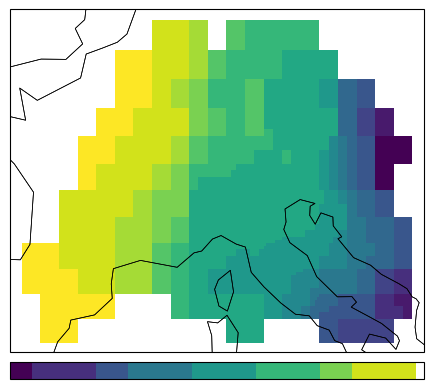

Damping value: 3630780.5477010175


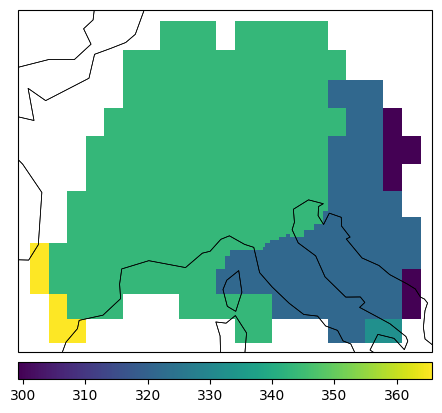

Damping value: 10000000.0


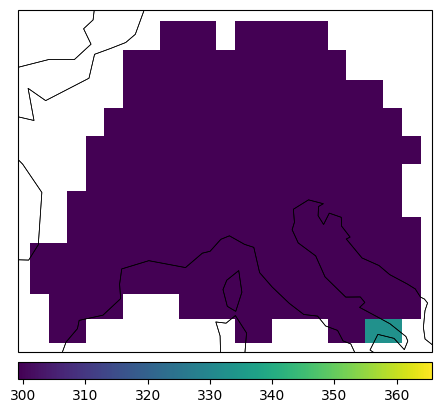

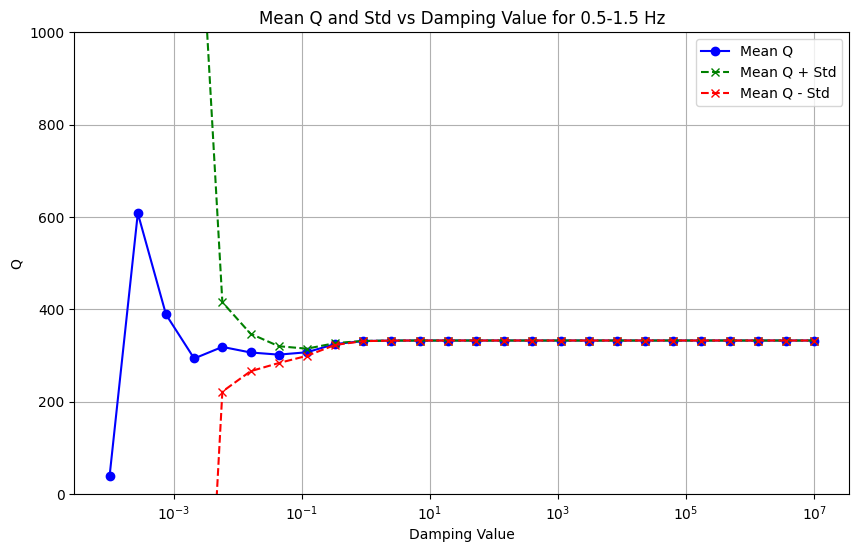

In [7]:
rdamping_values = np.logspace(-4, 7, num=int(5 / 0.2) + 1)
Q_different_damping = np.zeros((len(rdamping_values), 5)) 
for i, damping in enumerate(rdamping_values):
    print(f"Damping value: {damping}")
    #Q = 1/tomo.solve(rdamp=damping, ndamp=1e-2)  this is the working original line
    Q = 1/tomo.solve(rdamp=damping, ndamp=0.002)

    Q_different_damping[i, 0] = damping
    Q_different_damping[i, 1] = np.mean(Q)
    Q_different_damping[i, 2] = np.std(Q)
    Q_different_damping[i, 3] = np.max(Q)
    Q_different_damping[i, 4] = np.min(Q)
    tomo.plot_map(tomo.grid.mesh, Q)

plt.figure(figsize=(10, 6))
plt.semilogx(rdamping_values, Q_different_damping[:, 1], label='Mean Q', color='blue', marker='o')
plt.semilogx(rdamping_values, Q_different_damping[:, 1] + Q_different_damping[:, 2], 
             label='Mean Q + Std', color='green', linestyle='--', marker='x')
plt.semilogx(rdamping_values, Q_different_damping[:, 1] - Q_different_damping[:, 2], 
             label='Mean Q - Std', color='red', linestyle='--', marker='x')
plt.title(f'Mean Q and Std vs Damping Value for {fmin}-{fmax} Hz')
plt.xlabel('Damping Value')
plt.ylim([0, 1000])
plt.ylabel('Q')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
noise = np.random.uniform(0, 50, size=matrix.shape[0])
matrix[:, -1] =  500 + noise
print("Updated matrix with noise added to the last column.")

Updated matrix with noise added to the last column.


In [11]:
matrix = matrix[~np.isinf(matrix).any(axis=1)]
print("New shape after removing rows with inf values:", matrix.shape)
print(np.mean(matrix[:, -1]))

New shape after removing rows with inf values: (40927, 5)
525.012879031873


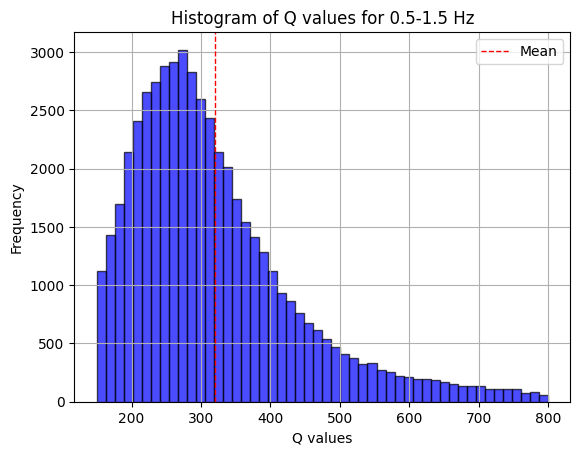

Mean Q value 319.44775476402083
Median Q value 292.2611158902078
Standard deviation Q value 120.03136824292817


In [84]:
plt.hist(matrix[:, -1], bins=50, color='blue', alpha=0.7, edgecolor='black')#,range=(-111, 1400))
plt.xlabel('Q values')
plt.ylabel('Frequency')
plt.title(f'Histogram of Q values for {fmin}-{fmax} Hz')
plt.axvline(np.mean(matrix[:, -1]), color='red', linestyle='dashed', linewidth=1, label='Mean')
plt.grid(True)
plt.legend()
plt.show()


print('Mean Q value',np.mean(matrix[:, -1]))
print('Median Q value',np.median(matrix[:, -1]))
print('Standard deviation Q value',np.std(matrix[:, -1]))

In [15]:
valid_count = 0
for event_data in Qkl.values():
    if not isinstance(event_data, dict): continue
    for sdata in event_data.get("stations", {}).values():
        if sdata.get("observable") is not None:
            valid_count += 1

print("Valid station-observations:", valid_count)


Valid station-observations: 57293


 updated matrix with noise added to the last column.
-------------------------------------
Optimal grid found in 91 iterations
-------------------------------------
-------------------------------------
GRID PARAMETERS
Lonmin - Lonmax : -180.000 - 180.000
Latmin - Latmax : -90.000 - 90.000
Number of cells : 41252
Grid cells of 1.000° : 41252
-------------------------------------
DATA PARAMETERS
Lonmin - Lonmax data : -4.153 - 19.948
Latmin - Latmax data : 40.078 - 51.997
Number of measurements : 40927
Source : Unknown
-------------------------------------

*** GRID UPDATED ***
-------------------------------------
GRID PARAMETERS
Lonmin - Lonmax : -5.502 - 21.223
Latmin - Latmax : 39.999 - 52.002
Number of cells : 211
Grid cells of 1.000° : 211
-------------------------------------
*** GRID UPDATED ***
-------------------------------------
GRID PARAMETERS
Lonmin - Lonmax : -5.502 - 21.057
Latmin - Latmax : 39.999 - 52.002
Number of cells : 191
Grid cells of 1.000° : 191
---------------

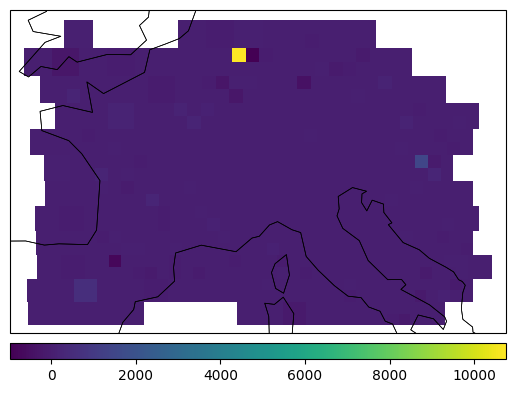

In [11]:
from seislib.tomography import SeismicTomography

ref = 3

noise = np.random.uniform(0, 30, size=matrix.shape[0])
matrix[:, -1] =  ref + noise
print(" updated matrix with noise added to the last column.")



tomo = SeismicTomography(cell_size=1, regular_grid=False, verbose=True)


tomo.add_data(data=matrix)
tomo.grid.set_boundaries(latmin=tomo.latmin_data,
                             latmax=tomo.latmax_data,
                             lonmin=tomo.lonmin_data,
                             lonmax=tomo.lonmax_data)


tomo.compile_coefficients(keep_empty_cells=False)

tomo.refine_parameterization(hitcounts=150,keep_empty_cells=True)    

slowness = 1 / matrix[:, -1]

Q = 1 / tomo.solve(refvel=ref)
print("Q shape:", Q.shape)
print("Mesh shape:", tomo.grid.mesh.shape)
tomo.plot_map(tomo.grid.mesh, Q)

In [132]:
print(tomo.grid)


-------------------------------------
GRID PARAMETERS
Lonmin - Lonmax : -3.766 - 21.057
Latmin - Latmax : 39.999 - 52.002
Number of cells : 579
Grid cells of 1.000° : 43
Grid cells of 0.500° : 536
-------------------------------------


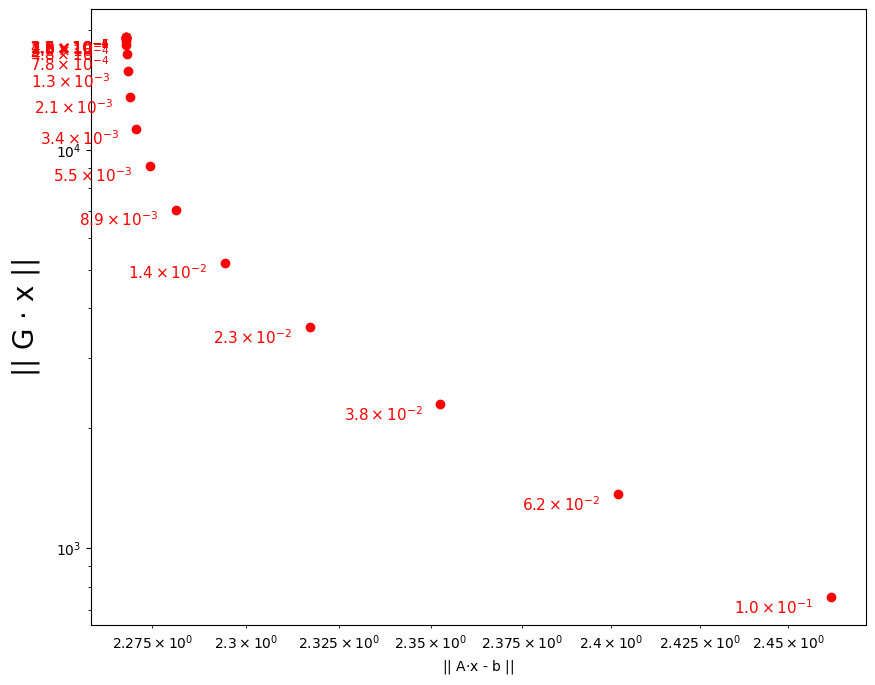

(array([1.00000000e-05, 1.62377674e-05, 2.63665090e-05, 4.28133240e-05,
        6.95192796e-05, 1.12883789e-04, 1.83298071e-04, 2.97635144e-04,
        4.83293024e-04, 7.84759970e-04, 1.27427499e-03, 2.06913808e-03,
        3.35981829e-03, 5.45559478e-03, 8.85866790e-03, 1.43844989e-02,
        2.33572147e-02, 3.79269019e-02, 6.15848211e-02, 1.00000000e-01]),
 [(2.268063617305648, 19152.858822722686),
  (2.2680649118956935, 19144.705482737714),
  (2.268064532360558, 19145.737645419395),
  (2.268066456379862, 19130.84039762481),
  (2.268074261981202, 19077.02060289148),
  (2.268065429312489, 19105.606384297975),
  (2.2680737306503786, 18999.833143045857),
  (2.2680839641604105, 18800.309907600797),
  (2.2681059223728353, 18359.545328000513),
  (2.268182068329814, 17400.03919125026),
  (2.268435216753616, 15733.477310217235),
  (2.269113275420211, 13566.47622359056),
  (2.270749600693394, 11294.126921120418),
  (2.274242897258077, 9115.52901638309),
  (2.281172464005624, 7077.23348016635

In [192]:
tomo.lcurve()

In [20]:
Q = 1/tomo.solve(rdamp=0.05)

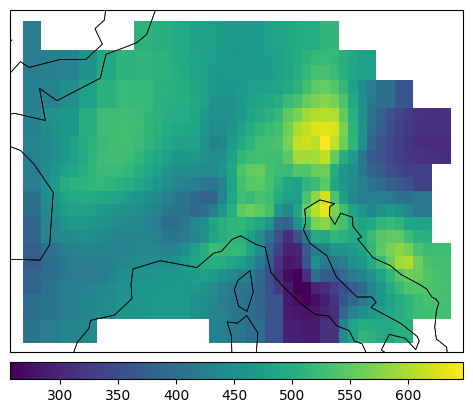

In [21]:
tomo.plot_map(tomo.grid.mesh, Q)

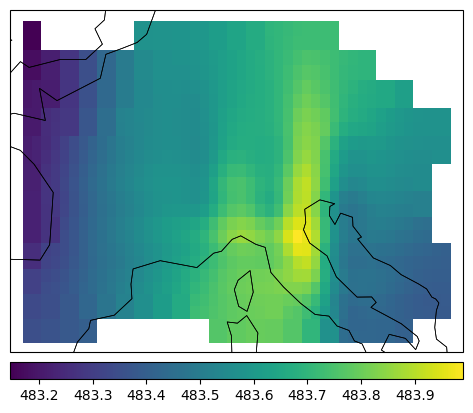

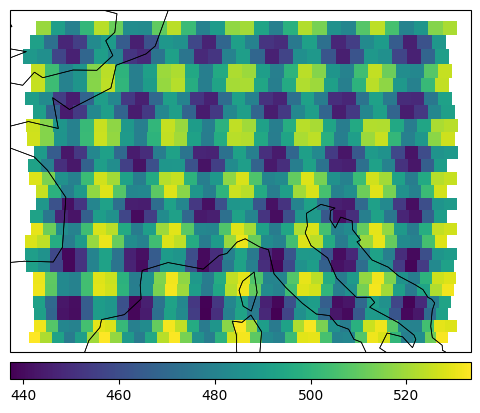

In [24]:
restest = tomo.checkerboard_test(kx=6,
                                 ky=6,
                                 latmin=tomo.grid.latmin,
                                 latmax=tomo.grid.latmax,
                                 lonmin=tomo.grid.lonmin,
                                 lonmax=tomo.grid.lonmax,
                                 cell_size=0.5,
                                 anom_amp=0.1,
                                 noise=0,
                                 rdamp=1)

input_model = 1 / restest['synth_model']
input_mesh = restest['mesh']
retrieved_model = 1 / restest['retrieved_model']

tomo.plot_map(tomo.grid.mesh, retrieved_model)
tomo.plot_map(input_mesh, input_model)


Text(0.5, 1.0, 'Raypaths per pixel')

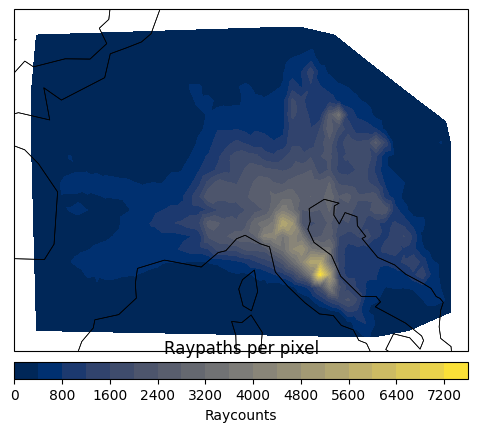

In [25]:
raypaths = tomo.raypaths_per_pixel()
img, cb = tomo.plot_map(mesh=tomo.grid.mesh, 
                        c=raypaths, 
                        cmap='cividis', 
                        style='contourf', 
                        levels=20,
                        show=False)
cb.set_label('Raycounts')
plt.title('Raypaths per pixel')

In [ ]:
from branca.colormap import LinearColormap

def plot_Qkl_map(Qkl_dict, fmin, fmax):
    Qkl_values = []
    for event in Qkl_dict.values():
        if 'stations' in event: 
            for station, station_data in event['stations'].items():
                Qkl = station_data.get('Qkl', None)
                if Qkl is not None and np.isfinite(Qkl):  # Filter out None and NaN values
                    Qkl_values.append(Qkl)

    if not Qkl_values:
        raise ValueError("No valid Qkl values found for plotting.")

    Qkl_values.sort()

    vmin = np.percentile(Qkl_values, 5)
    vmax = np.percentile(Qkl_values, 95)
    if vmin > vmax:
        vmin, vmax = sorted([vmin, vmax])

    colormap = LinearColormap(
        colors=["blue", "green", "yellow", "orange", "red"],
        vmin=vmin,
        vmax=vmax
    )

    latitudes = []
    longitudes = []

    for event in Qkl_dict.values():
        if 'coordinates' in event:
            event_lat = event['coordinates'].get('latitude')
            event_lon = event['coordinates'].get('longitude')
            if event_lat is not None and event_lon is not None:
                latitudes.append(event_lat)
                longitudes.append(event_lon)

        for station, station_data in event.get('stations', {}).items():
            station_lat = station_data['coordinates'].get('latitude')
            station_lon = station_data['coordinates'].get('longitude')
            if station_lat is not None and station_lon is not None:
                latitudes.append(station_lat)
                longitudes.append(station_lon)

    event_map = folium.Map(
        location=[np.mean(latitudes), np.mean(longitudes)],
        zoom_start=5,
        tiles="OpenStreetMap",
    )

    for event_time, event in Qkl_dict.items():
        if 'coordinates' not in event:
            continue
        event_lat = event['coordinates'].get('latitude')
        event_lon = event['coordinates'].get('longitude')

        if event_lat is None or event_lon is None:
            continue

        for station, station_data in event.get('stations', {}).items():
            Qkl = station_data.get('Qkl', None)
            if Qkl is None or not np.isfinite(Qkl):  # Skip invalid Qkl values
                continue

            station_lat = station_data['coordinates'].get('latitude')
            station_lon = station_data['coordinates'].get('longitude')

            folium.PolyLine(
                locations=[(event_lat, event_lon), (station_lat, station_lon)],
                color=colormap(Qkl), 
                weight=2,
                opacity=0.2,  # Set transparency
                tooltip=f"Event: {event_time}<br>Station: {station}<br>Qkl: {Qkl:.2f}"
            ).add_to(event_map)

    colormap.add_to(event_map)

    return event_map

Qkl_map = plot_Qkl_map(Qkl, fmin=0.5, fmax=1.5)
Qkl_map

#### Inversion testing

In order to find and understand the behaviour of the inversion, we will create a known model, and will try to retrieve it with the inversion. To do so, we can use all the real event-station couples, and calculate the path specific Qkl for each couple. Qkl will be computed by gridding the input model, fundamentally solving a forward problem. This Qkl is defined over a sum, of the multiplication of the length of a ray within a cell, and the cellvalue, normalised by the length of the ray. Doing this we can refind

This first code gives the chance to build a model specific to the wishes and place anomalies within the boundaries.

In [8]:
def model_building(basevalue=400, bloblist=[100, 1000], blobsizes=[4, 3], blobmiddles=[(50, 0), (46, 10)], 
                   latmin=40.078, latmax=52.078, lonmin=-2.827, lonmax=20.173, noise_value=None, checkerboard=False):
    """
    Create a grid model with optional blobs or a checkerboard pattern.

    Parameters:
        basevalue: float, the base value for the grid
        bloblist: list, values for the blobs
        blobsizes: list, sizes of the blobs
        blobmiddles: list of tuples, centers of the blobs (latitude, longitude)
        latmin, latmax: float, latitude boundaries
        lonmin, lonmax: float, longitude boundaries
        noise_value: float or None, standard deviation of noise to add to the grid
        checkerboard: bool, whether to create a checkerboard pattern

    Returns:
        grid: 2D numpy array, the generated grid
        lat: 2D numpy array, latitude values
        lon: 2D numpy array, longitude values
    """
    lat = np.linspace(latmin, latmax, 200)
    lon = np.linspace(lonmin, lonmax, 200)
    lon, lat = np.meshgrid(lon, lat)
    grid = np.full(lat.shape, basevalue, dtype=float)

    if checkerboard:
        lat_step = 2
        lon_step = 2
        for i in range(grid.shape[0]):
            for j in range(grid.shape[1]):
                if (int((lat[i, j] - latmin) / lat_step) + int((lon[i, j] - lonmin) / lon_step)) % 2 == 0:
                    grid[i, j] = 500
                else:
                    grid[i, j] = 1000
    else:
        for i in range(len(bloblist)):
            lat_blob = blobmiddles[i][0]
            lon_blob = blobmiddles[i][1]
            size_blob = blobsizes[i]
            value_blob = bloblist[i]
            grid[(lat - lat_blob)**2 + (lon - lon_blob)**2 < size_blob**2] = value_blob

    if noise_value is not None:
        noise = np.random.normal(-noise_value, noise_value, grid.shape)
        grid += noise

    return grid, lat, lon

bloblist = [1000]
blobmiddles = [(46, 10)]
blobsizes = [2]

model, lat, lon = model_building(checkerboard=True,bloblist=bloblist,blobmiddles=blobmiddles,blobsizes=blobsizes, latmin=40.078, latmax=52.078, lonmin=-4.827, lonmax=20.173)


This version of the model building creates N random anomalies within the boundaries.

In [138]:

def model_building(basevalue=400, N=5, value_range=(50, 1000), size_range=(1, 10), 
                   latmin=40.078, latmax=52.078, lonmin=-2.827, lonmax=20.173, noise_value=None):
    """
    Create a grid with a base value and N random blobs with random values, sizes, and locations.

    Parameters:
        basevalue: float, the base value for the grid
        N: int, number of blobs to create
        value_range: tuple, range of values for the blobs (min, max)
        size_range: tuple, range of sizes for the blobs (min, max)
        latmin, latmax: float, latitude boundaries
        lonmin, lonmax: float, longitude boundaries
        noise_value: float or None, standard deviation of noise to add to the grid

    Returns:
        grid: 2D numpy array, the generated grid
        lat: 2D numpy array, latitude values
        lon: 2D numpy array, longitude values
    """
    lat = np.linspace(latmin, latmax, 200)
    lon = np.linspace(lonmin, lonmax, 200)
    lon, lat = np.meshgrid(lon, lat)
    grid = np.full(lat.shape, basevalue, dtype=float)

    for _ in range(N):
        lat_blob = np.random.uniform(latmin, latmax)
        lon_blob = np.random.uniform(lonmin, lonmax)
        size_blob = np.random.uniform(size_range[0], size_range[1])
        value_blob = np.random.uniform(value_range[0], value_range[1])
        grid[(lat - lat_blob)**2 + (lon - lon_blob)**2 < size_blob**2] = value_blob

    if noise_value is not None:
        noise = np.random.normal(0, noise_value, grid.shape)
        grid += noise

    return grid, lat, lon


model, lat, lon = model_building(N=10, value_range=(100, 1500), size_range=(0.5, 2), 
                                 latmin=40.078, latmax=52.078, lonmin=-4.827, lonmax=20.173)




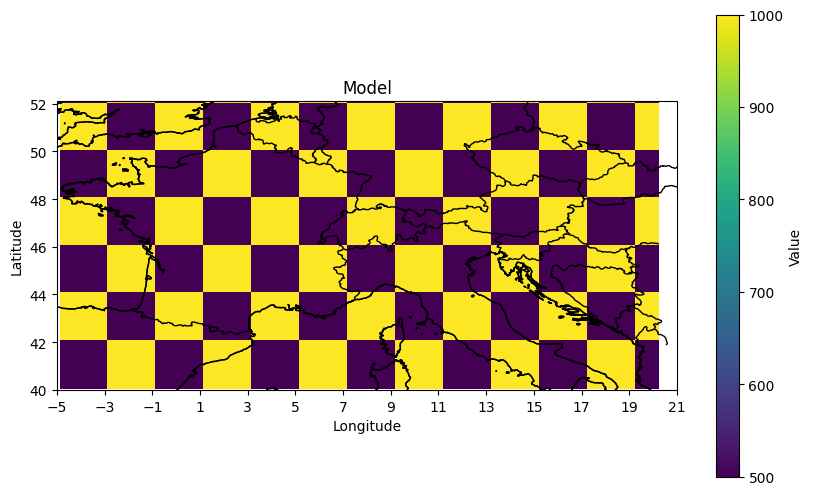

In [9]:
def plot_model(lat, lon, grid):
    fig = plt.figure(figsize=(10, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())

    c = ax.pcolormesh(lon, lat, grid, shading='auto', cmap='viridis', transform=ccrs.PlateCarree())
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle='-', edgecolor='black')
    ax.add_feature(cfeature.COASTLINE, edgecolor='black')

    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

    ax.set_xticks(np.arange(np.floor(lon.min()), np.ceil(lon.max()) + 1, 2), crs=ccrs.PlateCarree())
    ax.set_yticks(np.arange(np.floor(lat.min()), np.ceil(lat.max()) + 1, 2), crs=ccrs.PlateCarree())
    ax.tick_params(labelsize=10)

    ax.set_title('Model')
    fig.colorbar(c, ax=ax, orientation='vertical', label='Value')

    plt.show()


plot_model(lat, lon, model)



In [16]:
from geopy.distance import geodesic
from skimage.draw import line

def forward_modelling(couples, model, lat_grid, lon_grid):
    results = []
    latmin, latmax = lat_grid[:, 0].min(), lat_grid[:, 0].max()
    lonmin, lonmax = lon_grid[0, :].min(), lon_grid[0, :].max()

    for (event, station) in couples:
        lat1, lon1 = event
        lat2, lon2 = station

        lat1 = np.clip(lat1, latmin, latmax)
        lon1 = np.clip(lon1, lonmin, lonmax)
        lat2 = np.clip(lat2, latmin, latmax)
        lon2 = np.clip(lon2, lonmin, lonmax)

        y1 = np.argmin(np.abs(lat_grid[:, 0] - lat1))
        x1 = np.argmin(np.abs(lon_grid[0, :] - lon1))
        y2 = np.argmin(np.abs(lat_grid[:, 0] - lat2))
        x2 = np.argmin(np.abs(lon_grid[0, :] - lon2))

        #print(f"Event (lat, lon): ({lat1}, {lon1}) → index ({y1}, {x1})")
        #print(f"Station (lat, lon): ({lat2}, {lon2}) → index ({y2}, {x2})")
        #print("Delta indices:", abs(y2 - y1), abs(x2 - x1))

        rr, cc = line(y1, x1, y2, x2)
        #print(f"Total segments: {len(rr)}")
        if len(rr) == 0:
            #print("No path found between event and station.")
            continue

        q_vals = []
        dists = []

        for i in range(len(rr) - 1):
            q = model[rr[i], cc[i]]
            lat_a = lat_grid[rr[i], cc[i]]
            lon_a = lon_grid[rr[i], cc[i]]
            lat_b = lat_grid[rr[i + 1], cc[i + 1]]
            lon_b = lon_grid[rr[i + 1], cc[i + 1]]
            dist = geodesic((lat_a, lon_a), (lat_b, lon_b)).km

            q_vals.append(q)
            dists.append(dist)

        total_dist = np.sum(dists)
        if total_dist == 0:
            avg_q = model[y1, x1]
        else:
            avg_q = np.sum(np.array(q_vals) * np.array(dists)) / total_dist

        results.append([lat1, lon1, lat2, lon2, avg_q])

    return np.array(results)

def plot_paths(model, lat_grid, lon_grid, couples):
    plt.figure(figsize=(10, 8))
    plt.pcolormesh(lon_grid, lat_grid, model, shading='auto', cmap='viridis')
    plt.colorbar(label='Q value')

    for (event, station) in couples:
        lat1, lon1 = event
        lat2, lon2 = station
        plt.plot([lon1, lon2], [lat1, lat2], color='red', linewidth=1)
        plt.scatter(lon1, lat1, color='blue', marker='*', s=100,
                    label='Event' if 'Event' not in plt.gca().get_legend_handles_labels()[1] else "")
        plt.scatter(lon2, lat2, color='white', edgecolor='black', marker='o', s=50,
                    label='Station' if 'Station' not in plt.gca().get_legend_handles_labels()[1] else "")

    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title('Paths over Q Model')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

#couples_tuple = [((48, 0), (50, 15))]

#model, lat, lon = model_building(bloblist=[50, 1500], blobsizes=[6, 5])


#plot_model(lat,lon,model)
couples = matrix[:20000, :-1]

couples_tuple = [((row[0], row[1]), (row[2], row[3])) for row in couples]
results = forward_modelling(couples_tuple, model, lat, lon)

print("Results:")
print(results)


results = results[(results[:, -1] > 150) & (results[:, -1] <= 1500)]
results = results[~np.isinf(results).any(axis=1)]
results = results[~np.isnan(results).any(axis=1)]


#plot_paths(model, lat, lon, couples_tuple)


Results:
[[ 43.741       15.174       43.5644       7.1234     750.85151441]
 [ 43.741       15.174       43.4917       5.3325     705.59347726]
 [ 43.741       15.174       43.7528       6.9218     746.15384615]
 ...
 [ 42.7959      13.0745      46.547901    13.5149     924.78280133]
 [ 42.7959      13.0745      46.2829      12.0472     713.26651303]
 [ 42.7959      13.0745      46.234       13.2438     797.07681609]]


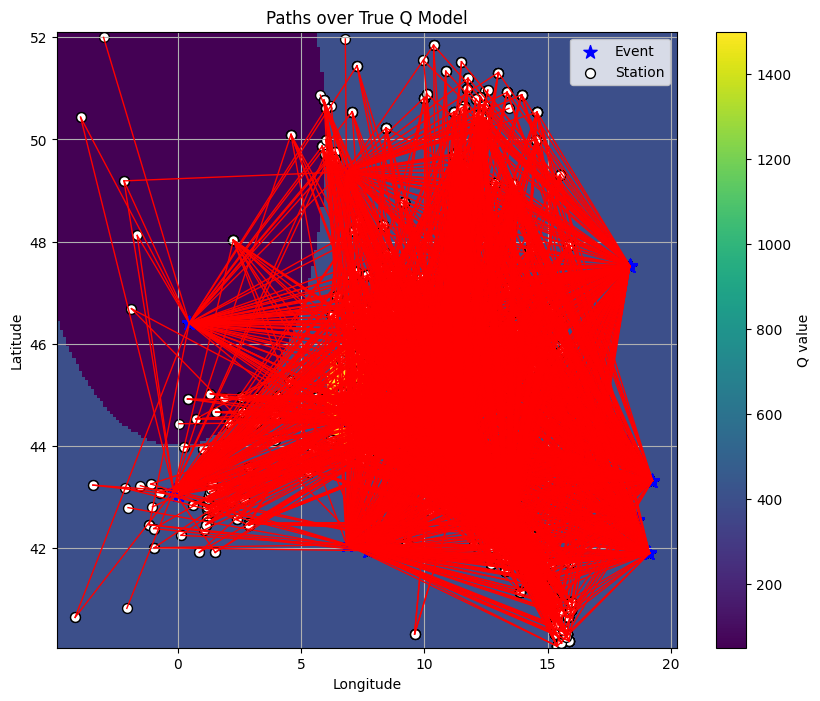

In [31]:

def plot_paths(model, lat_grid, lon_grid, couples):
    """
    Plot the Q model and the event-station paths.
    
    Parameters:
        model: 2D numpy array of Q values
        lat_grid: 2D array of latitudes
        lon_grid: 2D array of longitudes
        couples: list of ((lat_event, lon_event), (lat_station, lon_station)) pairs
    """
    plt.figure(figsize=(10, 8))
    
    plt.pcolormesh(lon_grid, lat_grid, model, shading='auto', cmap='viridis')
    plt.colorbar(label='Q value')
    
    for (event, station) in couples:
        lat1, lon1 = event
        lat2, lon2 = station
        plt.plot([lon1, lon2], [lat1, lat2], color='red', linewidth=1)
        
        plt.scatter(lon1, lat1, color='blue', marker='*', s=100, label='Event' if 'Event' not in plt.gca().get_legend_handles_labels()[1] else "")
        plt.scatter(lon2, lat2, color='white', edgecolor='black', marker='o', s=50, label='Station' if 'Station' not in plt.gca().get_legend_handles_labels()[1] else "")
    
    plt.xlabel('Longitude')
    
    plt.ylabel('Latitude')
    plt.title('Paths over True Q Model')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_paths(model, lat, lon, couples_tuple)


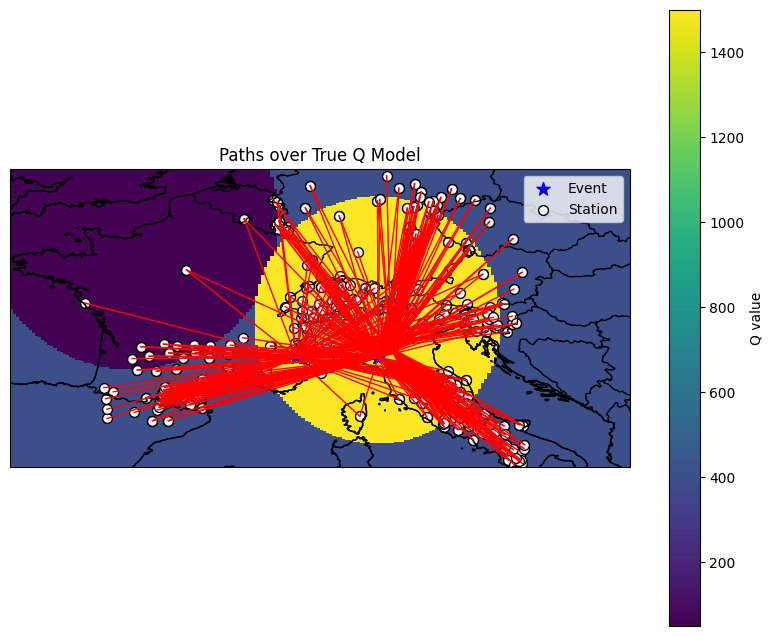

In [50]:
def plot_paths(model, lat_grid, lon_grid, couples):
    """
    Plot the Q model and the event-station paths.
    
    Parameters:
        model: 2D numpy array of Q values
        lat_grid: 2D array of latitudes
        lon_grid: 2D array of longitudes
        couples: list of ((lat_event, lon_event), (lat_station, lon_station)) pairs
    """
    plt.figure(figsize=(10, 8))
    
    ax = plt.axes(projection=ccrs.PlateCarree())
    pcolormesh = ax.pcolormesh(lon_grid, lat_grid, model, shading='auto', cmap='viridis', transform=ccrs.PlateCarree())
    plt.colorbar(pcolormesh, ax=ax, label='Q value')
    
    for (event, station) in couples:
        lat1, lon1 = event
        lat2, lon2 = station
        ax.plot([lon1, lon2], [lat1, lat2], color='red', linewidth=1, transform=ccrs.PlateCarree())
        
        ax.scatter(lon1, lat1, color='blue', marker='*', s=100, label='Event' if 'Event' not in plt.gca().get_legend_handles_labels()[1] else "", transform=ccrs.PlateCarree())
        ax.scatter(lon2, lat2, color='white', edgecolor='black', marker='o', s=50, label='Station' if 'Station' not in plt.gca().get_legend_handles_labels()[1] else "", transform=ccrs.PlateCarree())
    
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle='-', edgecolor='black')
    ax.add_feature(cfeature.COASTLINE, edgecolor='black')
    
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title('Paths over True Q Model')
    ax.legend()
    ax.grid(True)
    plt.show()

plot_paths(model, lat, lon, couples_tuple)


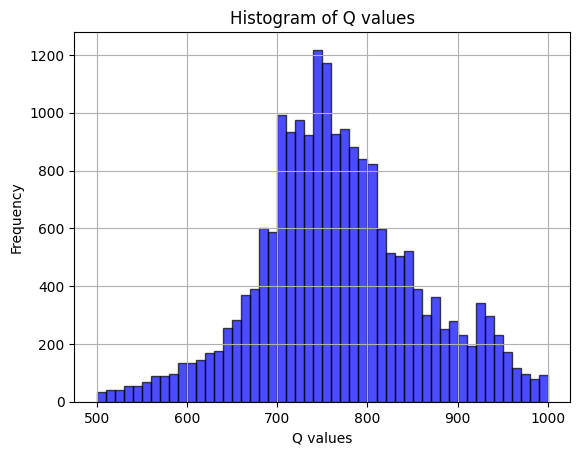

Mean Q value 767.6131079225415
Median Q value 759.7469854807678
Standard deviation Q value 89.43748687590494


In [18]:
plt.hist(results[:, -1], bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel('Q values')
plt.ylabel('Frequency')
plt.title('Histogram of Q values')
plt.grid(True)
plt.show()


print('Mean Q value',np.mean(results[:, -1]))
print('Median Q value',np.median(results[:, -1]))
print('Standard deviation Q value',np.std(results[:, -1]))

Now we explore the damping once again.

In [135]:
#this cell can be run if we want to add noise to the results 
noise = np.random.uniform(0, 50, size=results.shape[0])
noisy_results = results.copy()
for i in range(len(results[:, -1])):
    noisy_results[i, -1] =  results[i,-1] + noise[i]

In [17]:
tomo = SeismicTomography(cell_size=1, 
                         regular_grid=True, 
                        latmin=40.078,
                             latmax=51.966,
                             lonmin=-2.827 ,
                             lonmax=19.948,
                         verbose=True)

tomo.add_data(data=results)
print(tomo.latmin_data,tomo.latmax_data,tomo.lonmin_data,tomo.lonmax_data)

tomo.grid.set_boundaries(latmin=tomo.latmin_data,
                             latmax=tomo.latmax_data,
                             lonmin=tomo.lonmin_data,
                             lonmax=tomo.lonmax_data)


tomo.compile_coefficients(keep_empty_cells=False)

tomo.refine_parameterization(hitcounts=150,keep_empty_cells=True)    
tomo.refine_parameterization(hitcounts=150,keep_empty_cells=True)    
#tomo.refine_parameterization(hitcounts=150,keep_empty_cells=True)    




-------------------------------------
GRID PARAMETERS
Lonmin - Lonmax : -2.827 - 20.173
Latmin - Latmax : 40.078 - 52.078
Number of cells : 276
Grid cells of 1.000° : 276
-------------------------------------
DATA PARAMETERS
Lonmin - Lonmax data : -2.827 - 19.354
Latmin - Latmax data : 40.078 - 51.966
Number of measurements : 20000
Source : Unknown
-------------------------------------

40.0783 51.9663 -2.8274 19.354
*** GRID UPDATED ***
-------------------------------------
GRID PARAMETERS
Lonmin - Lonmax : -2.827 - 20.173
Latmin - Latmax : 40.078 - 52.078
Number of cells : 276
Grid cells of 1.000° : 276
-------------------------------------
*** GRID UPDATED ***
-------------------------------------
GRID PARAMETERS
Lonmin - Lonmax : -2.827 - 20.173
Latmin - Latmax : 40.078 - 52.078
Number of cells : 243
Grid cells of 1.000° : 243
-------------------------------------
*** GRID UPDATED ***
-------------------------------------
GRID PARAMETERS
Lonmin - Lonmax : -2.827 - 20.173
Latmin - L

In [ ]:


rdamping_values = np.logspace(-4, 5, num=int(5 / 0.5) + 1)
Q_different_damping = np.zeros((len(rdamping_values), 5))  # Adjusted array size to match ndamping_values
for i, damping in enumerate(rdamping_values):
    print(f"Damping value: {damping}")
    Q = 1/tomo.solve(rdamp=damping, ndamp=1e-2)
    Q_different_damping[i, 0] = damping
    Q_different_damping[i, 1] = np.mean(Q)
    Q_different_damping[i, 2] = np.std(Q)
    Q_different_damping[i, 3] = np.max(Q)
    Q_different_damping[i, 4] = np.min(Q)
    tomo.plot_map(tomo.grid.mesh, Q)

plt.figure(figsize=(10, 6))
plt.semilogx(rdamping_values, Q_different_damping[:, 1], label='Std Q', color='blue', marker='o')
#plt.ylim([0,500])
plt.title('Mean Q vs Damping Value')
plt.xlabel('Damping Value')
plt.ylabel('Mean Q')
#plt.plot(damping_values, Q_different_damping[:, 2], label='Std Q')
#
plt.show()

Again we find an rdamping of 0.05 suitable, so we can write:

In [19]:
def plot_seislib_grid(meshndarray, c, Qkl_dict = Qkl):
    fig = plt.figure(figsize=(10, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())

    min_lon = np.min(np.minimum(meshndarray[:, 2], meshndarray[:, 3]))
    max_lon = np.max(np.maximum(meshndarray[:, 2], meshndarray[:, 3]))
    min_lat = np.min(np.minimum(meshndarray[:, 0], meshndarray[:, 1]))
    max_lat = np.max(np.maximum(meshndarray[:, 0], meshndarray[:, 1]))

    padding = 1.0
    ax.set_extent([min_lon - padding, max_lon + padding, 
                   min_lat - padding, max_lat + padding], crs=ccrs.PlateCarree())

    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.LAND, edgecolor='black', alpha=0.3)

    patches = []
    colors = []

    for i in range(meshndarray.shape[0]):
        lat1, lat2, lon1, lon2 = meshndarray[i]
        lon = min(lon1, lon2)
        lat = min(lat1, lat2)
        width = abs(lon2 - lon1)
        height = abs(lat2 - lat1)
        rect = Rectangle((lon, lat), width, height)
        patches.append(rect)
        colors.append(c[i])

    p = PatchCollection(patches, cmap='viridis', edgecolor='k', linewidth=0.5)
    p.set_array(np.array(colors))
    ax.add_collection(p)

    from matplotlib.ticker import FuncFormatter

    def fixed_formatter(x, pos):
        return f"{x:.0f}" 

    cb = plt.colorbar(p, ax=ax, orientation='vertical', label='Value')
    cb.ax.yaxis.set_major_formatter(FuncFormatter(fixed_formatter))    
    ax.set_title(f" Retrieved Q ")

    #for event_data in Qkl_dict.values():
    #    event_coords = event_data["coordinates"]
    #    ax.plot(event_coords["longitude"], event_coords["latitude"], 'ro', markersize=3)
    plt.show()

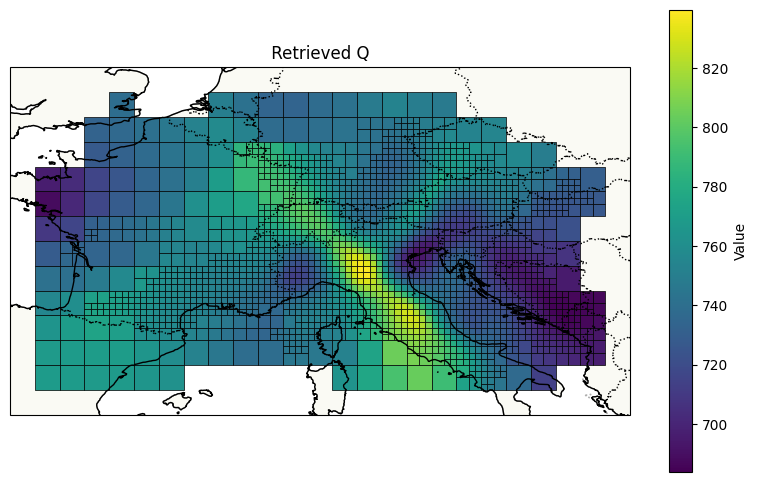

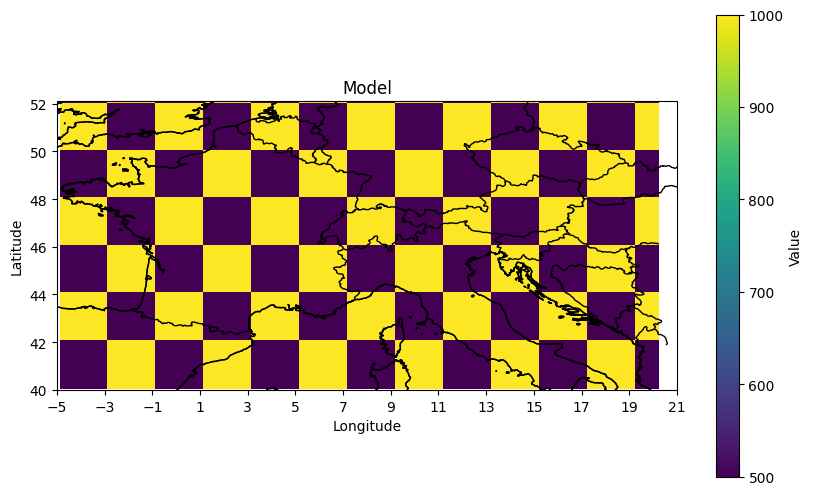

Mean Q value 748.5129084252526
maximum Q value 839.596569051433


In [20]:
Q = 1/tomo.solve(rdamp=0.05, ndamp=1e-2)
Q = np.clip(Q, 0, 2000)
plot_seislib_grid(tomo.grid.mesh, Q)
plot_model(lat,lon,model)



print('Mean Q value',np.mean(Q))
print('maximum Q value',np.max(Q))

In [41]:
def print_key_structure(d, indent=0):
    if isinstance(d, dict):
        for key, value in d.items():
            print("  " * indent + f"- {key}")
            print_key_structure(value, indent + 1)
    elif isinstance(d, list) and d and isinstance(d[0], dict):
        for i, item in enumerate(d):
            print("  " * indent + f"[{i}]")
            print_key_structure(item, indent + 1)
    else:
        print("  " * indent + f": {type(d).__name__}")



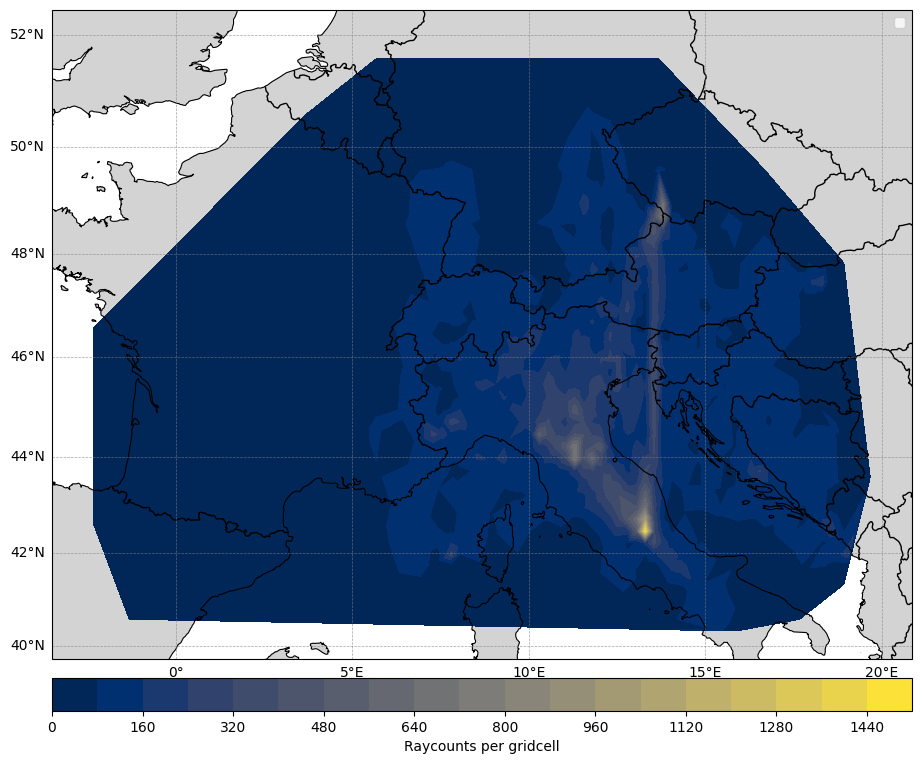

In [148]:
def plot_raycoverage(tomo, Qkl=Qkl,fmin=fmin,fmax=fmax):
    """
    Plot the ray coverage on a map using Cartopy.
    
    Parameters:
        tomo: SeismicTomography object
        Qkl: dictionary containing event and station data
    """
    import matplotlib.pyplot as plt
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    fig = plt.figure(figsize=(10, 8))
    ax = plt.axes(projection=ccrs.Mercator())

    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.7, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 10, 'color': 'black'}
    gl.ylabel_style = {'size': 10, 'color': 'black'}

    ax.add_feature(cfeature.BORDERS, linewidth=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.LAND, facecolor='lightgray')

    raypaths = tomo.raypaths_per_pixel()
    img, cb = tomo.plot_map(mesh=tomo.grid.mesh, 
                            c=raypaths, 
                            cmap='cividis', 
                            style='contourf', 
                            levels=20,
                            ax=ax,
                            show=False)

    cb.set_label('Raycounts per gridcell')

    #for event_data in Qkl.values():
    #    event_coords = event_data["coordinates"]
    #    ax.plot(event_coords["longitude"], event_coords["latitude"],
    #            'ro', markersize=3, transform=ccrs.PlateCarree(), label="Event")

    #for event_data in Qkl.values():
    #    for station_code, station_info in event_data.get("stations", {}).items():
    #        if station_info.get("Qkl") is not None:
    #            station_coords = station_info.get("coordinates", {})
    #            lat = station_coords.get("latitude")
    #            lon = station_coords.get("longitude")
    #            if lat is not None and lon is not None:
    #                ax.plot(lon, lat, 'b^', markersize=3, transform=ccrs.PlateCarree(), label="Station")

    #fig.suptitle(f"Ray Coverage with Events and Stations for frequency range {fmin}-{fmax}Hz", fontsize=14, y=1.0001)    
    handles, labels = ax.get_legend_handles_labels()
    unique_handles_labels = [(h, l) for i, (h, l) in enumerate(zip(handles, labels)) if l not in labels[:i]]
    ax.legend(*zip(*unique_handles_labels), loc='upper right', fontsize=10)

    plt.tight_layout(pad=2.0) 
    plt.show()

plot_raycoverage(tomo, Qkl=Qkl)


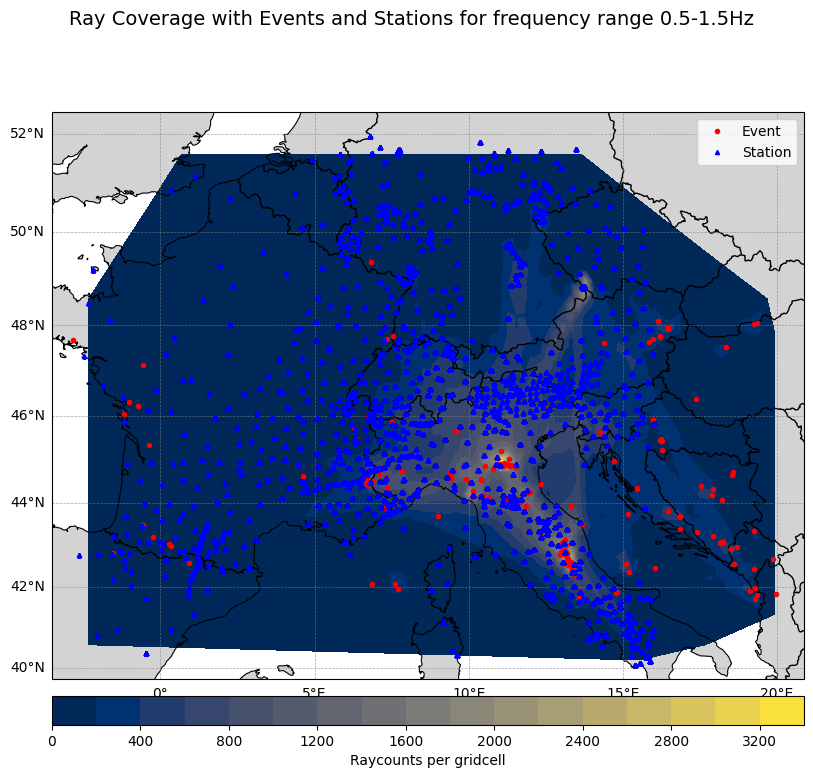

In [21]:
def plot_raycoverage(tomo, Qkl=Qkl, fmin=fmin, fmax=fmax):
    """
    Plot the ray coverage on a map using Cartopy.
    
    Parameters:
        tomo: SeismicTomography object
        Qkl: dictionary containing event and station data
    """
    import matplotlib.pyplot as plt
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    fig = plt.figure(figsize=(10, 8))
    ax = plt.axes(projection=ccrs.Mercator())

    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.7, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 10, 'color': 'black'}
    gl.ylabel_style = {'size': 10, 'color': 'black'}

    ax.add_feature(cfeature.BORDERS, linewidth=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.LAND, facecolor='lightgray')

    raypaths = tomo.raypaths_per_pixel()
    img, cb = tomo.plot_map(mesh=tomo.grid.mesh, 
                            c=raypaths, 
                            cmap='cividis', 
                            style='contourf', 
                            levels=20,
                            ax=ax,
                            show=False)

    cb.set_label('Raycounts per gridcell')

    for event_data in Qkl.values():
        event_coords = event_data["coordinates"]

        valid_station_found = False
        for station_code, station_info in event_data.get("stations", {}).items():
            if station_info.get("Qkl") is not None:
                valid_station_found = True
                break 

        if valid_station_found:  
            ax.plot(event_coords["longitude"], event_coords["latitude"],
                    'ro', markersize=3, transform=ccrs.PlateCarree(), label="Event")

    for event_data in Qkl.values():
        for station_code, station_info in event_data.get("stations", {}).items():
            if station_info.get("Qkl") is not None:
                station_coords = station_info.get("coordinates", {})
                lat = station_coords.get("latitude")
                lon = station_coords.get("longitude")
                if lat is not None and lon is not None:
                    ax.plot(lon, lat, 'b^', markersize=3, transform=ccrs.PlateCarree(), label="Station")

    fig.suptitle(f"Ray Coverage with Events and Stations for frequency range {fmin}-{fmax}Hz", fontsize=14, y=1)

    handles, labels = ax.get_legend_handles_labels()
    unique_handles_labels = [(h, l) for i, (h, l) in enumerate(zip(handles, labels)) if l not in labels[:i]]
    ax.legend(*zip(*unique_handles_labels), loc='upper right', fontsize=10)

    plt.tight_layout(pad=3.0)  
    plt.show()

plot_raycoverage(tomo, Qkl=Qkl, fmin=fmin, fmax=fmax)


##### Different ray coverage
Now we can explore how exactly the ray coverage influences the recovery of the model. We have tested with the true distribution of station and events, and will here model with an artificial distribution.


In [22]:
def ray_distribution(nstation=100, nevents=50, distribution='uniform', area_of_high_density=None, area_of_high_event_density=None,
                     latmin=40.078, latmax=52.078, lonmin=-2.827, lonmax=20.173):
    """
    Generate all station-event pairs within 800 km based on a specified distribution.
    
    Returns:
        A numpy array of shape (N, 4), where each row contains:
        [event_lat, event_lon, station_lat, station_lon]
    """

    def haversine(lat1, lon1, lat2, lon2):
        lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
        dlat = lat2 - lat1
        dlon = lon2 - lon1
        a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
        c = 2 * np.arcsin(np.sqrt(a))
        r = 6371  
        return c * r

    if distribution == 'uniform':
        lat_stations = np.random.uniform(latmin, latmax, nstation)
        lon_stations = np.random.uniform(lonmin, lonmax, nstation)

    elif distribution == 'regular_grid':
        lat_stations = np.linspace(latmin, latmax, int(np.sqrt(nstation)))
        lon_stations = np.linspace(lonmin, lonmax, int(np.sqrt(nstation)))
        lat_stations, lon_stations = np.meshgrid(lat_stations, lon_stations)
        lat_stations = lat_stations.flatten()
        lon_stations = lon_stations.flatten()
        nstation = len(lat_stations)
    elif distribution == 'normal':
        lat_stations = np.random.normal(loc=(latmin + latmax) / 2, scale=(latmax - latmin) / 6, size=nstation)
        lon_stations = np.random.normal(loc=(lonmin + lonmax) / 2, scale=(lonmax - lonmin) / 6, size=nstation)
    elif distribution == 'lognormal':
        lat_stations = np.random.lognormal(mean=np.log((latmin + latmax) / 2), sigma=0.5, size=nstation)
        lon_stations = np.random.lognormal(mean=np.log((lonmin + lonmax) / 2), sigma=0.5, size=nstation)
    else:
        raise ValueError("Invalid distribution type. Choose 'uniform', 'normal', or 'lognormal'.")

    lat_stations = np.clip(lat_stations, latmin, latmax)
    lon_stations = np.clip(lon_stations, lonmin, lonmax)

    event_latitudes = np.random.uniform(latmin, latmax, nevents)
    event_longitudes = np.random.uniform(lonmin, lonmax, nevents)

    if area_of_high_density is not None:
        for area_point in area_of_high_density:
            center_lat, center_lon = area_point
            for _ in range(30):
                angle = np.random.uniform(0, 2 * np.pi)
                radius = np.random.uniform(0, 1)
                new_lat = center_lat + radius * np.cos(angle)
                new_lon = center_lon + radius * np.sin(angle)
                lat_stations = np.append(lat_stations, new_lat)
                lon_stations = np.append(lon_stations, new_lon)
        nstation = len(lat_stations)


    if area_of_high_event_density is not None:
        for area_point in area_of_high_event_density:
            center_lat, center_lon = area_point
            for _ in range(30):
                angle = np.random.uniform(0, 2 * np.pi)
                radius = np.random.uniform(0, 1)
                new_lat = center_lat + radius * np.cos(angle)
                new_lon = center_lon + radius * np.sin(angle)
                event_latitudes = np.append(event_latitudes, new_lat)
                event_longitudes = np.append(event_longitudes, new_lon)
        nevents = len(event_latitudes)



    ray_matrix = []

    for i in range(nevents):
        ev_lat = event_latitudes[i]
        ev_lon = event_longitudes[i]
        for j in range(nstation):
            st_lat = lat_stations[j]
            st_lon = lon_stations[j]
            distance = haversine(ev_lat, ev_lon, st_lat, st_lon)
            if distance < 800:  
                ray_matrix.append([ev_lat, ev_lon, st_lat, st_lon])

    return np.array(ray_matrix)


rays = ray_distribution(nstation=1000, nevents=200, distribution='regular_grid')  #,area_of_high_density=[(45, 10), (46, 12)],area_of_high_event_density=[(45, 10), (46, 12)]
print("Number of valid rays:", len(rays))


Number of valid rays: 97861


In [ ]:
couples = rays[:, :]
couples_tuple = [((row[0], row[1]), (row[2], row[3])) for row in couples]
bloblist=[1000]

blobsizes=[1]
blobmiddles=[(46, 8)]
model,lat,lon = model_building(checkerboard=True,bloblist=bloblist,blobsizes=blobsizes,blobmiddles=blobmiddles, latmin=40.078, latmax=52.078, lonmin=-4.827, lonmax=20.173)
#plot_model(lat, lon, model)
results = forward_modelling(couples_tuple, model, lat, lon)


In [128]:
tomo = SeismicTomography(cell_size=1, 
                         regular_grid=True, 
                        latmin=40.078,
                             latmax=51.966,
                             lonmin=-2.827 ,
                             lonmax=19.948,
                         verbose=True)

tomo.add_data(data=results)
print(tomo.latmin_data,tomo.latmax_data,tomo.lonmin_data,tomo.lonmax_data)

tomo.grid.set_boundaries(latmin=tomo.latmin_data,
                             latmax=tomo.latmax_data,
                             lonmin=tomo.lonmin_data,
                             lonmax=tomo.lonmax_data)


tomo.compile_coefficients(keep_empty_cells=False)

tomo.refine_parameterization(hitcounts=150,keep_empty_cells=True)    
tomo.refine_parameterization(hitcounts=150,keep_empty_cells=True) 
tomo.refine_parameterization(hitcounts=150,keep_empty_cells=True) 
#tomo.refine_parameterization(hitcounts=150,keep_empty_cells=True) 


Q = 1/tomo.solve(rdamp=0.0008, ndamp=1e-2)
Q = np.clip(Q, 0, 2000)
plot_seislib_grid(tomo.grid.mesh, Q)
plot_model(lat,lon,model)



print('Mean Q value',np.mean(Q))
print('maximum Q value',np.max(Q))

-------------------------------------
GRID PARAMETERS
Lonmin - Lonmax : -2.827 - 20.173
Latmin - Latmax : 40.078 - 52.078
Number of cells : 276
Grid cells of 1.000° : 276
-------------------------------------
DATA PARAMETERS
Lonmin - Lonmax data : -2.827 - 20.173
Latmin - Latmax data : 40.078 - 52.078
Number of measurements : 94485
Source : Unknown
-------------------------------------

40.078 52.078 -2.827 20.173
*** GRID UPDATED ***
-------------------------------------
GRID PARAMETERS
Lonmin - Lonmax : -2.827 - 20.173
Latmin - Latmax : 40.078 - 52.078
Number of cells : 276
Grid cells of 1.000° : 276
-------------------------------------
*** GRID UPDATED ***
-------------------------------------
GRID PARAMETERS
Lonmin - Lonmax : -2.827 - 20.173
Latmin - Latmax : 40.078 - 52.078
Number of cells : 276
Grid cells of 1.000° : 276
-------------------------------------
*** GRID UPDATED ***
-------------------------------------
GRID PARAMETERS
Lonmin - Lonmax : -2.827 - 20.173
Latmin - Latm

: 

In [105]:
def get_mean_value_around_coordinate(meshndarray, values, lat, lon, radius=0.5):
    """
    Calculate the mean value of grid cells around a given coordinate within a specified radius.

    Parameters:
        meshndarray: numpy.ndarray, the grid mesh containing latitudes and longitudes
        values: numpy.ndarray, the values corresponding to the grid cells
        lat: float, latitude of the coordinate
        lon: float, longitude of the coordinate
        radius: float, radius in degrees (default is 0.5)

    Returns:
        float: mean value of the grid cells within the radius
    """
    distances = np.sqrt((meshndarray[:, 0] - lat)**2 + (meshndarray[:, 2] - lon)**2)
    mask = distances <= radius
    selected_values = values[mask]
    if len(selected_values) == 0:
        return None 
    return np.mean(selected_values)

latitude = 46.0
longitude = 8.0
mean_value = get_mean_value_around_coordinate(tomo.grid.mesh, Q, latitude, longitude)
print(f"Mean value around ({latitude}, {longitude}) within 0.5 degrees: {mean_value}")

Mean value around (46.0, 8.0) within 0.5 degrees: 1018.1857654547456


Damping value: 0.0001


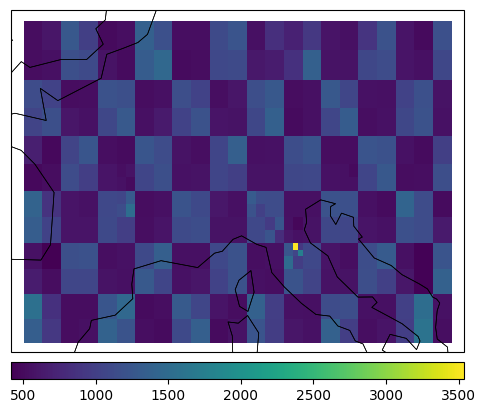

Damping value: 0.0007943282347242813


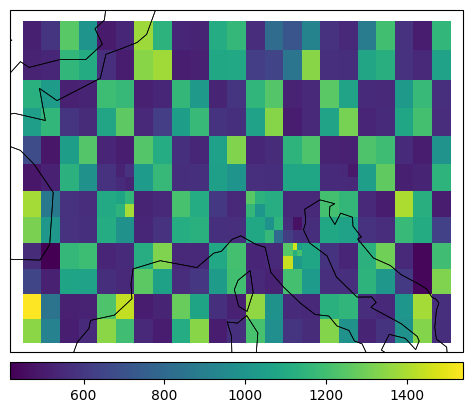

Damping value: 0.00630957344480193


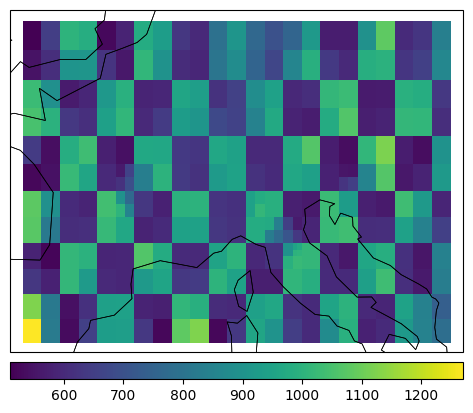

Damping value: 0.05011872336272725


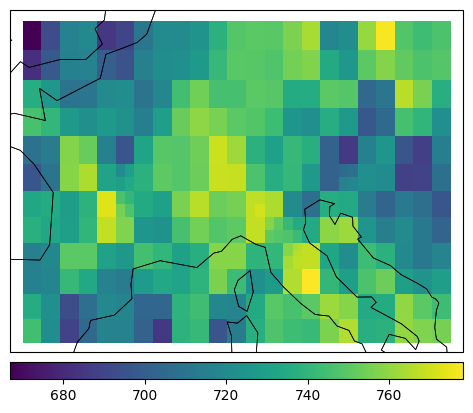

Damping value: 0.3981071705534973


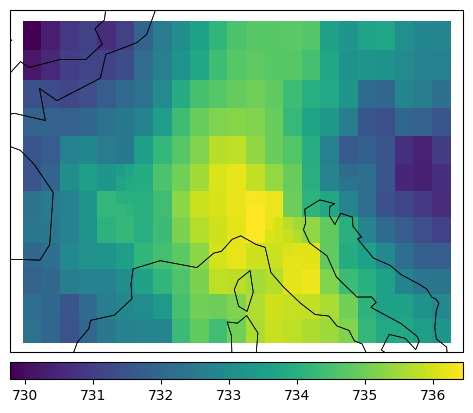

Damping value: 3.1622776601683795


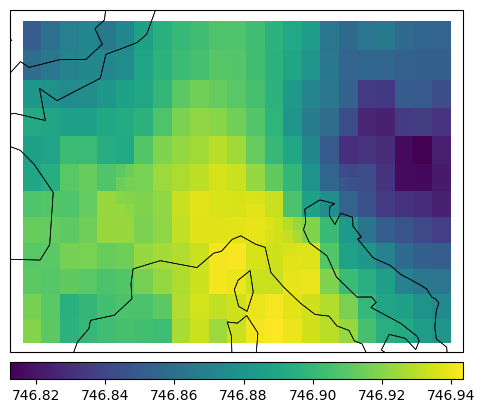

Damping value: 25.11886431509582


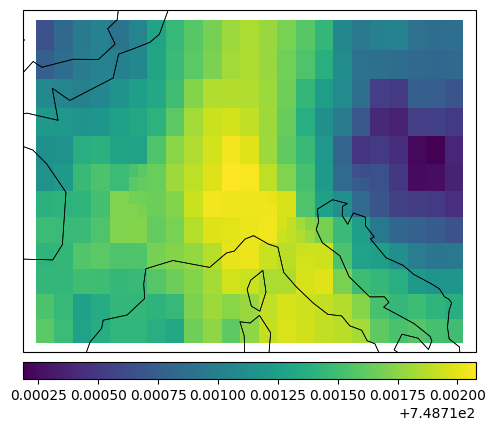

Damping value: 199.52623149688787


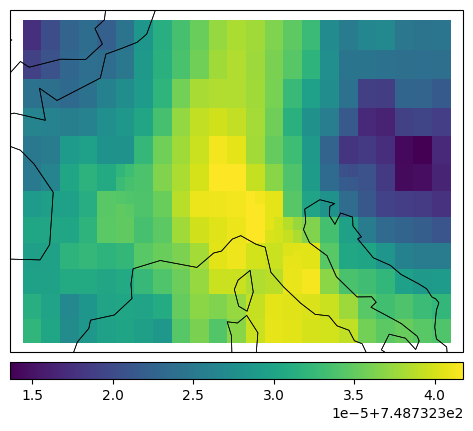

Damping value: 1584.893192461114


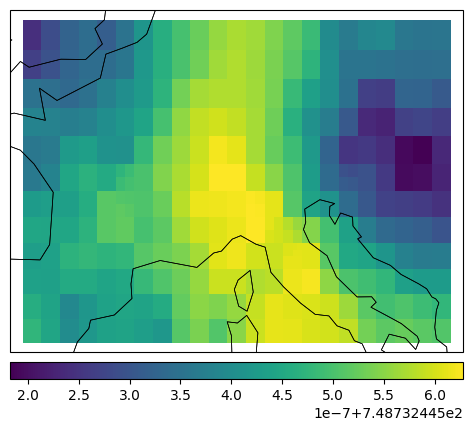

Damping value: 12589.254117941662


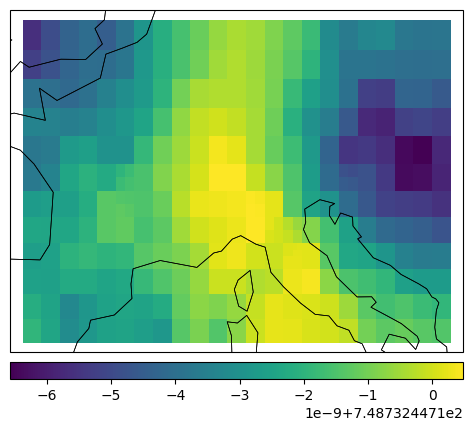

Damping value: 100000.0


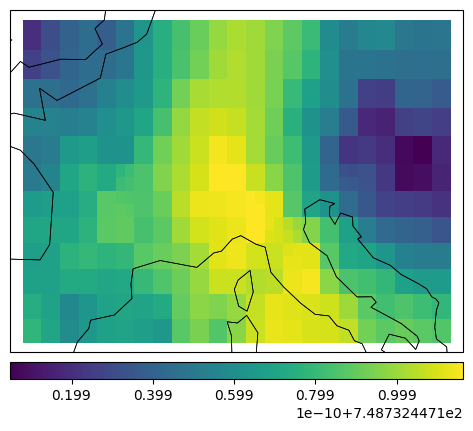

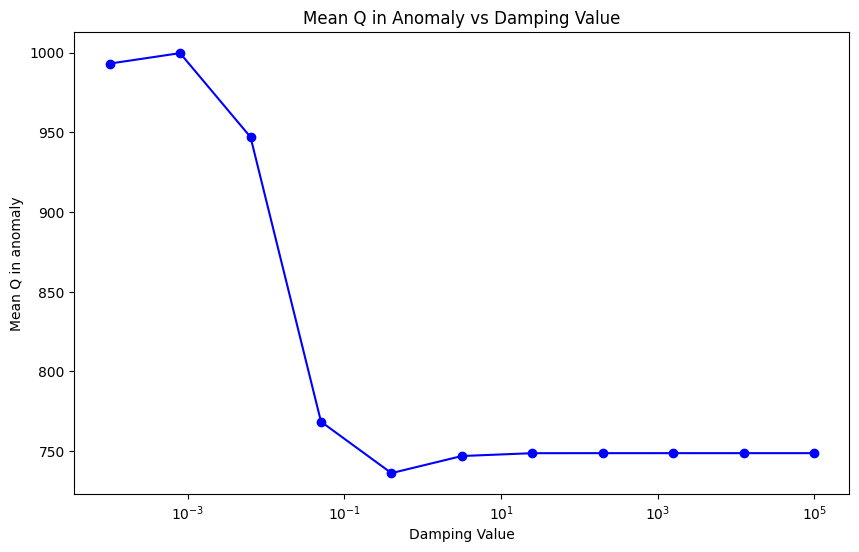

In [124]:

mean_vals_in_anomaly = []
rdamping_values = np.logspace(-4, 5, num=int(5 / 0.5) + 1)
Q_different_damping = np.zeros((len(rdamping_values), 5))  # Adjusted array size to match ndamping_values
for i, damping in enumerate(rdamping_values):
    print(f"Damping value: {damping}")
    Q = 1/tomo.solve(rdamp=damping, ndamp=1e-2)
    Q_different_damping[i, 0] = damping
    Q_different_damping[i, 1] = np.mean(Q)
    Q_different_damping[i, 2] = np.std(Q)
    Q_different_damping[i, 3] = np.max(Q)
    Q_different_damping[i, 4] = np.min(Q)
    mean_value = get_mean_value_around_coordinate(tomo.grid.mesh, Q, 46, 8)
    mean_vals_in_anomaly.append(mean_value)
    tomo.plot_map(tomo.grid.mesh, Q)

plt.figure(figsize=(10, 6))
plt.semilogx(rdamping_values, mean_vals_in_anomaly, label='Mean value', color='blue', marker='o')
#plt.ylim([0,500])
plt.title('Mean Q in Anomaly vs Damping Value')
plt.xlabel('Damping Value')
plt.ylabel('Mean Q in anomaly')
#plt.plot(damping_values, Q_different_damping[:, 2], label='Std Q')
#
plt.show()

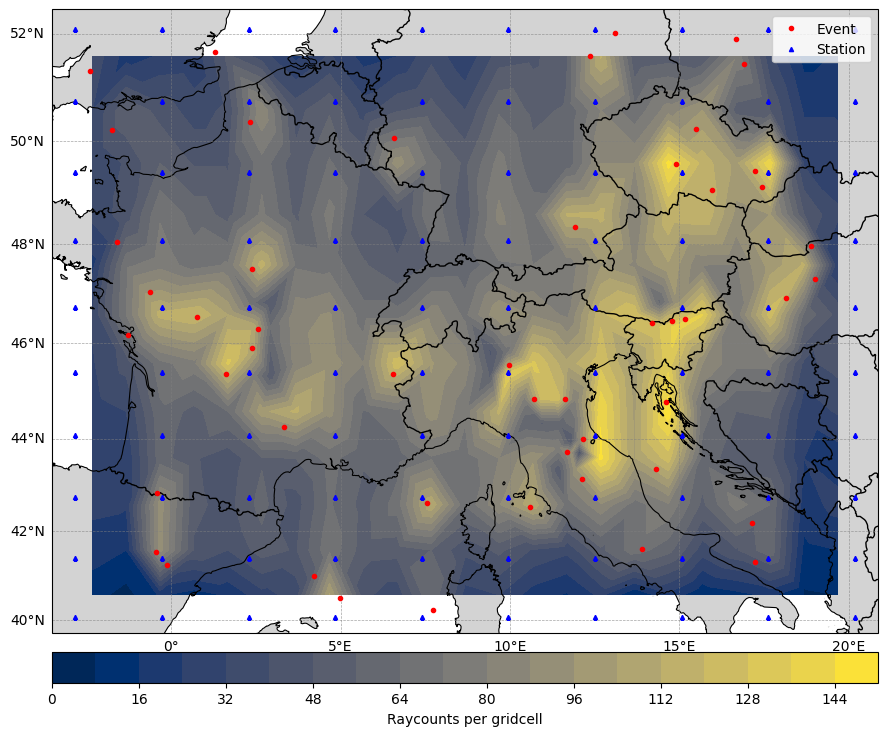

In [125]:
from matplotlib.patches import Circle
from cartopy.mpl.patch import geos_to_path

def plot_raycoverage_artificial_dist(tomo, ray_array, blobmiddles=None, blobsizes=None):
        import cartopy.crs as ccrs
        import cartopy.feature as cfeature

        fig = plt.figure(figsize=(10, 8))
        ax = plt.axes(projection=ccrs.Mercator())

        gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.7, linestyle='--')
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {'size': 10, 'color': 'black'}
        gl.ylabel_style = {'size': 10, 'color': 'black'}

        ax.add_feature(cfeature.BORDERS, linewidth=1)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
        ax.add_feature(cfeature.LAND, facecolor='lightgray')

        raypaths = tomo.raypaths_per_pixel()
        img, cb = tomo.plot_map(mesh=tomo.grid.mesh, 
                                                        c=raypaths, 
                                                        cmap='cividis', 
                                                        style='contourf', 
                                                        levels=20,
                                                        ax=ax,
                                                        show=False)
        cb.set_label('Raycounts per gridcell')

        ray_array = np.array(ray_array)
        events = ray_array[:, :2]
        stations = ray_array[:, 2:]

        unique_events = np.unique(events, axis=0)
        unique_stations = np.unique(stations, axis=0)

        ax.plot(unique_events[:, 1], unique_events[:, 0], 'ro', markersize=3,
                        transform=ccrs.PlateCarree(), label='Event')

        ax.plot(unique_stations[:, 1], unique_stations[:, 0], 'b^', markersize=3,
                        transform=ccrs.PlateCarree(), label='Station')

        if blobmiddles is not None and blobsizes is not None:
                for center, radius in zip(blobmiddles, blobsizes):
                        blob_circle = Circle((center[1], center[0]), radius=radius, 
                                                                edgecolor='red', facecolor='none', linewidth=1.5,
                                                                transform=ccrs.PlateCarree())
                        ax.add_patch(blob_circle)

        #fig.suptitle(f"Ray Coverage with Events, Stations, and Blob Contours",fontsize=14, y=1)

        handles, labels = ax.get_legend_handles_labels()
        unique_handles_labels = [(h, l) for i, (h, l) in enumerate(zip(handles, labels)) if l not in labels[:i]]
        ax.legend(*zip(*unique_handles_labels), loc='upper right', fontsize=10)

        plt.tight_layout(pad=3.0)
        plt.show()



plot_raycoverage_artificial_dist(tomo=tomo, ray_array=rays)

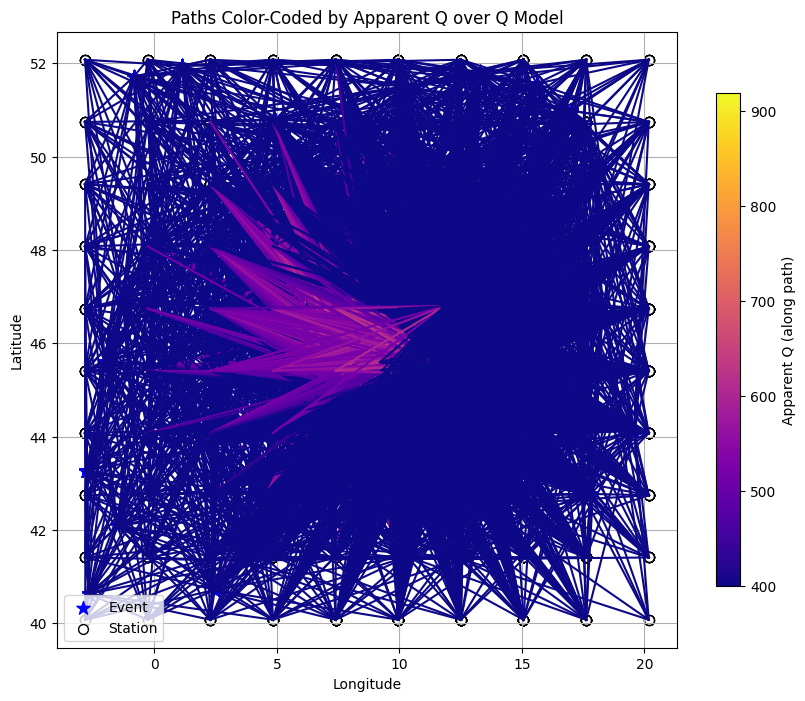

In [69]:
def plot_paths_q_colored(results):
    from matplotlib import colors as mcolors
    fig, ax = plt.subplots(figsize=(10, 8))
    
   
    q_values = results[:, 4]
    norm = mcolors.Normalize(vmin=np.min(q_values), vmax=np.max(q_values))
    cmap = plt.cm.plasma
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])  # Required dummy array

    for row in results:
        lat1, lon1, lat2, lon2, q = row
        color = cmap(norm(q))
        ax.plot([lon1, lon2], [lat1, lat2], color=color, linewidth=1.5)

    events = results[:, :2]
    stations = results[:, 2:4]
    
    ax.scatter(events[:, 1], events[:, 0], color='blue', marker='*', s=100, label='Event')
    ax.scatter(stations[:, 1], stations[:, 0], color='white', edgecolor='black', marker='o', s=50, label='Station')
    
    fig.colorbar(sm, ax=ax, label='Apparent Q (along path)', shrink=0.8)

    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title('Paths Color-Coded by Apparent Q over Q Model')
    ax.legend()
    ax.grid(True)
    plt.show()
    

plot_paths_q_colored(results)